# 逐交易日主力合约识别

本方法使用正式 silver 的合约日线与日历，首个有效交易日按当天成交量最大合约初始化，当天生效；此后在信号交易日收盘后决定下一交易日的主力，并保存选择依据。主力路径按交易日递推，初始化使用固定读取历史；输出起点只决定结果截取。

本 Notebook 面向熟悉 Python 和期货合约的研究人员，包含可导入的函数定义、只读数据读取与 CU／RB demo 计算单元格。算法不读取文件；演示单元格显式读取数据并调用算法。下游可根据每日映射读取分钟行情，收益、复权和波动率由相应方法定义。

本演示基于当前湖快照，尚不具备历史逐时点数据版本，不能仅凭信号日约束证明历史输入没有修订。

## 环境与权威契约

使用 `Python (latitude_env_v2)` 内核。根目录按环境模板定位；下面的 Schema 浏览仅展示契约，不读取数据。四张表按依赖顺序列出，实际读取与 demo 均由后续单元格启动。

In [1]:
import hashlib
import json
import pathlib
import sys
import time

# 项目根目录是整个仓库的顶层目录。
# 从当前工作目录向上查找，同时包含下面三个标记的目录就是项目根目录。
project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))  # 项目配置和数据契约所在目录
        sys.path.insert(0, str(candidate_root / "04_Research"))  # 研究方法所在目录
        sys.path.insert(0, str(candidate_root / "02_Market_Data/a01_Collection"))  # 采集及共用展示模块所在目录
        break
else:
    raise RuntimeError("未找到项目根目录")

print(sys.executable)  # 当前 Python 解释器的文件路径

# PyArrow 是处理 Arrow 列式数据的 Python 库。
# Dataset 把目录中的多个数据文件作为一张逻辑表读取。
import pyarrow.dataset as ds

# IPython 是交互式 Python 环境，display 是其中的对象展示函数。
from IPython.display import display

# Schema 是表结构定义，规定字段名、类型、是否允许空值及描述信息。
# 下面导入四张上游表的权威定义，以及项目统一的类型转换函数。
from config.data_contracts import (
    FUTURES_VARIETY_CALENDAR_SCHEMA,  # 品种交易日历
    FUTURES_CONTRACT_CALENDAR_SCHEMA,  # 合约交易日历
    FUTURES_BAR_CALENDAR_SCHEMA,  # 行情采集日历
    FUTURES_DAILY_SCHEMA,  # 合约每日行情
    arrow_to_pandas,  # 将 Arrow 表转换为使用统一字段类型的 Pandas DataFrame
)

from config.settings import settings  # 项目配置对象，包含正式数据湖路径等参数
from b00_03_notebook_schema_browser import display_schema_metadata  # 项目提供的表结构展示函数

# metadata 是附在 Schema 上的描述信息，以下三个键分别表示：
# table_name：表在数据湖中的目录名。
# partition_columns：分区字段，决定数据文件按哪些字段值分目录保存。
# primary_key：主键字段，其组合用于唯一标识一条记录。
# metadata 的值是字节串，decode() 转为文本；split(",") 将字段名拆成列表。

# 品种交易日历。
VARIETY_CALENDAR_TABLE_NAME = FUTURES_VARIETY_CALENDAR_SCHEMA.metadata[b"table_name"].decode()
VARIETY_CALENDAR_PARTITION_COLUMNS = FUTURES_VARIETY_CALENDAR_SCHEMA.metadata[b"partition_columns"].decode().split(",")
VARIETY_CALENDAR_PRIMARY_KEY = FUTURES_VARIETY_CALENDAR_SCHEMA.metadata[b"primary_key"].decode().split(",")

# 合约交易日历。
CONTRACT_CALENDAR_TABLE_NAME = FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata[b"table_name"].decode()
CONTRACT_CALENDAR_PARTITION_COLUMNS = FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata[b"partition_columns"].decode().split(",")
CONTRACT_CALENDAR_PRIMARY_KEY = FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata[b"primary_key"].decode().split(",")

# 行情采集日历。
BAR_CALENDAR_TABLE_NAME = FUTURES_BAR_CALENDAR_SCHEMA.metadata[b"table_name"].decode()
BAR_CALENDAR_PARTITION_COLUMNS = FUTURES_BAR_CALENDAR_SCHEMA.metadata[b"partition_columns"].decode().split(",")
BAR_CALENDAR_PRIMARY_KEY = FUTURES_BAR_CALENDAR_SCHEMA.metadata[b"primary_key"].decode().split(",")

# 合约每日行情。
DAILY_TABLE_NAME = FUTURES_DAILY_SCHEMA.metadata[b"table_name"].decode()
DAILY_PARTITION_COLUMNS = FUTURES_DAILY_SCHEMA.metadata[b"partition_columns"].decode().split(",")
DAILY_PRIMARY_KEY = FUTURES_DAILY_SCHEMA.metadata[b"primary_key"].decode().split(",")

LAKE_ROOT = settings.futures_lake_root  # 正式数据湖根目录，其下包含 raw、silver 等目录

# 展示标签是一个字典：键为原英文字段名，值为“英文字段名（中文含义）”。
# field_name_zh 是权威 Schema 为字段定义的中文名称。
# 这些字典只用于展示副本，不改变计算和落盘使用的字段名。
variety_calendar_column_labels = {
    field.name: f"{field.name}（{field.metadata[b'field_name_zh'].decode('utf-8')}）"
    for field in FUTURES_VARIETY_CALENDAR_SCHEMA
}
contract_calendar_column_labels = {
    field.name: f"{field.name}（{field.metadata[b'field_name_zh'].decode('utf-8')}）"
    for field in FUTURES_CONTRACT_CALENDAR_SCHEMA
}
bar_calendar_column_labels = {
    field.name: f"{field.name}（{field.metadata[b'field_name_zh'].decode('utf-8')}）"
    for field in FUTURES_BAR_CALENDAR_SCHEMA
}
daily_column_labels = {
    field.name: f"{field.name}（{field.metadata[b'field_name_zh'].decode('utf-8')}）"
    for field in FUTURES_DAILY_SCHEMA
}

# 候选表是展示本次参与主力选择的合约及其相关数据的表。
# 它使用三张上游表的字段，因此合并对应标签；** 表示展开已有字典。
# 最后三个字段由主力选择过程生成，在此补充中文含义。
#
# 生效日：采用本次主力选择结果的交易日。
# 决策前主力：本次选择之前记住的最近一次主力合约。
candidate_column_labels = {
    **contract_calendar_column_labels,
    **daily_column_labels,
    **bar_calendar_column_labels,
    "eligible_on_effective_date": "eligible_on_effective_date（生效日是否具备交易资格）",
    "selected": "selected（是否选为主力）",
    "later_than_incumbent": "later_than_incumbent（退市日是否晚于决策前主力）",
}

E:\anaconda3\envs\latitude_env_v2\python.exe


In [2]:
display_schema_metadata([
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_DAILY_SCHEMA,
])

## 1. 输入、时间与证据

| 输入 | 方法使用的信息 |
|---|---|
| 品种交易日历 | `trading_date` 形成逐日递推网格；初始化取当日信息，之后取上一交易日信息 |
| 合约交易时段日历 | `contract_code`、`list_date`、`delist_date` 及生效日是否存在交易时段，多个 Session 折叠到合约—交易日 |
| 日线采集日历 | 只取 `bar_frequency=1d`；`is_fetch_completed`、`actual_bar_count` 判断完成与空结果，`is_fetch_required` 仅解释未完成原因 |
| 合约日线 | `has_market_data`、`volume`、`open_interest` 提供比较与并列排序证据 |

字段定义以[数据契约](../../../config/data_contracts.py)为准，检查范围遵循[上游契约与研究校验](../../AGENTS.md#上游契约与研究校验)。正式 silver 已保证的主键、Schema／metadata、水位和业务质量不在研究层重复校验；读取仍使用 PyArrow Dataset、权威 Schema 和统一 Arrow 转换入口。

本方法需要确认目标交易所与品种的样本范围、初始化所需历史、Session 折叠后的合约资格、日线事实与完成凭证的对应关系，以及信号日信息能否支持候选比较。已完成的空结果与未知证据须分别处理，不能由字段类型一致推定候选证据齐备。第 5 节检查本方法生成的交易日映射、换约决策和输出稳定性；这些属于研究处理自身的结果性质。未受正式仓库契约保证的外部或合成输入，按来源和上述计算前提检查。

记信息所属交易日为 $s$，主力生效日为 $t$。初始化使用首个有效交易日的完整成交量，当日生效，$s=t$；这是使用当日收盘信息建立历史起点的特例。初始化完成后，$s$ 为 $t$ 的上一交易日，只用 $s$ 日已完成日线确定 $t$ 日主力。夜盘沿用正式日历交易日归属。

固定读取历史从统一采集起点开始，首个证据齐备且存在正成交量候选的交易日，直接选取当天成交量最大合约并记为当天主力。此前无法初始化的日期保留未识别；输出起点只裁剪已有路径，不重新初始化。日期端点均包含在内，范围内实际日期由品种日历决定。

## 2. 选择规则

### 初始化与排序

尚无已识别主力时，逐交易日用当日数据尝试初始化；首次成功时选择当天成交量最大合约，并令 `is_roll=false`。初始化使用当日完整成交量，不能解释为当日开盘前已知的选择。此后的保留与换约使用前一交易日信息。

候选须在信号日合约日历中存在，在生效日仍有交易资格，且信号日日线已完成并具有有效正成交量。依次按成交量降序、持仓量降序（缺失排后）、退市日期升序、合约代码升序选择第一名。初始化不设置在线合约数量门槛。

### 保留与正常换约

“现主力”是最后一次成功识别的合约，不必等于上一行可能为空的输出。挑战者须晚于现主力退市，按上述排序选出。现主力仍可交易且其成交量可比较时，仅在

$$
V_{\mathrm{challenger},s}>r\,V_{\mathrm{incumbent},s}
$$

成立时换约，否则保留。$r$ 是有限且不小于 1 的显式参数，本例取 1.10。恰好达到门槛不换约；没有有效后月挑战者且证据齐备时保留。

### 到期与证据不足

| 条件 | 实现处理 |
|---|---|
| 现主力已超过退市日期 | 有完整证据的有效后月候选时强制换约，不要求旧合约成交量可用 |
| 到期无后月候选 | 当日未识别，内部保留最后已识别状态 |
| 尚未完成采集或缺少必需格点/事实/成交量 | 当日未识别，不自动保留或换约；缺失不能填零 |
| 已完成且 `actual_bar_count=0`，或事实 `has_market_data=false` | 确认该合约不能提供正成交量候选；若为现主力且未到期，当日未识别 |
| 现主力有有效数值零成交量 | 零参与比较，正成交量后月可严格超过门槛 |
| 合约仍在上市区间却缺少生效日或现主力信号日日历 | 当日未识别，不能把日历缺口当成到期 |
| 某个参与排序的候选证据未知 | 阻断当日选择，不能假定缺失候选不会胜出 |

未识别日期保留原因及可空换约标记，内部状态不重置；后续再次选择仍只向更晚退市合约切换。当前 `is_fetch_required=false` 不撤销已保存的历史完成凭证。

In [3]:
from __future__ import annotations

import math
from datetime import date

import pandas as pd
import pyarrow as pa

MAIN_CONTRACT_SELECTION_VERSION = "1.0.0"  # 主力选择方法的版本标识，记录结果采用哪一版实现

# Schema 是每日主力选择结果的表结构，规定字段名、类型及是否允许空值。
# nullable=False 表示不可为空；未指定时默认允许为空。
# date32 表示只有年月日的日期，float64 表示双精度浮点数，int32 表示整数，bool 表示真假值。
MAIN_CONTRACT_DAILY_SCHEMA = pa.schema([
    # 这一行属于哪个交易所、品种，以及哪一天。
    pa.field("exchange_code", pa.string(), nullable=False),  # 交易所代码，例如 XSGE
    pa.field("underlying_code", pa.string(), nullable=False),  # 品种代码，例如 CU、RB
    pa.field("trading_date", pa.date32(), nullable=False),  # 采用本次主力选择结果的交易日
    pa.field("signal_trading_date", pa.date32()),  # 比较成交量所用的交易日；初始化时为当天，之后为前一交易日

    # 原主力是本次选择之前，最近一次成功选出的主力。
    pa.field("incumbent_contract_code", pa.string()),  # 原主力合约代码；初始化时为空
    pa.field("incumbent_delist_date", pa.date32()),  # 原主力的退市日期

    # 挑战者是符合条件的后续候选中排名第一的合约。
    pa.field("challenger_contract_code", pa.string()),  # 挑战者合约代码；初始化或没有挑战者时为空
    pa.field("challenger_delist_date", pa.date32()),  # 挑战者的退市日期

    # 本次选择的最终结果：可能保留原主力，也可能选择挑战者。
    pa.field("main_contract_code", pa.string()),  # 当日最终选出的主力合约；当前实现未识别时为空
    pa.field("main_delist_date", pa.date32()),  # 当日最终主力的退市日期

    # 以下成交量都属于 signal_trading_date，不一定属于结果生效的交易日。
    pa.field("incumbent_signal_volume", pa.float64()),  # 原主力在信号日的成交量
    pa.field("challenger_signal_volume", pa.float64()),  # 挑战者在信号日的成交量
    pa.field("selected_signal_volume", pa.float64()),  # 最终选出的主力在信号日的成交量

    # 记录本次参与比较的候选情况。
    pa.field("candidate_count", pa.int32(), nullable=False),  # 符合选择条件且具有有效正成交量的候选数量
    pa.field("unavailable_candidate_count", pa.int32(), nullable=False),  # 当前实现中因所需数据不可用而无法判断的候选数量

    # 状态表示选择结果，原因解释为什么得到这个结果。
    # 状态包括 initialized 初始化、held 保留、rolled 正常换约、
    # forced_roll 到期换约，以及当前实现支持的 unresolved 未识别。
    pa.field("selection_status", pa.string(), nullable=False),  # 本次选择的状态标签
    pa.field("selection_reason", pa.string(), nullable=False),  # 本次选择的具体原因
    pa.field("is_roll", pa.bool_()),  # 是否从原主力切换到另一个合约；初始化为 False，未识别时为空
    pa.field("roll_trigger_ratio", pa.float64(), nullable=False),  # 正常换约的成交量倍数门槛，例如 1.10
], metadata={
    # metadata 是附在表结构上的描述信息；Arrow 要求键和值使用字节串。
    b"method_name": b"main_contract_selection",  # 生成这张表的方法名称
    b"method_version": MAIN_CONTRACT_SELECTION_VERSION.encode(),  # 方法版本；encode() 将文本转为字节串
    b"grain_zh": "一行对应一个品种的一个目标交易日，包括未识别日期".encode(),  # 说明每一行代表什么
})

In [4]:
def build_main_contract_daily(
    variety_calendar_df: pd.DataFrame,
    contract_calendar_df: pd.DataFrame,
    daily_df: pd.DataFrame,
    bar_calendar_df: pd.DataFrame,
    *,
    exchange_code: str,
    underlying_code: str,
    output_start_date: str | date | None = None,
    output_end_date: str | date | None = None,
    roll_trigger_ratio: float = 1.10,
) -> pd.DataFrame:
    """首个有效日按当日成交量初始化，随后按上一交易日信息递推。

    Args:
        variety_calendar_df: 品种交易日历，确定交易日顺序。
        contract_calendar_df: 合约日历，确定交易资格与退市日期。
        daily_df: 合约日线，提供成交量、持仓量及行情有效标记。
        bar_calendar_df: 日线采集日历，判断数据是否完成采集。
        exchange_code: 交易所代码，如 "XSGE"。
        underlying_code: 品种代码，如 "RB"。
        output_start_date: 输出起点，含当日；此前历史仍参与递推。
        output_end_date: 输出终点，含当日；None 表示不限制。
        roll_trigger_ratio: 换约成交量倍数门槛，默认 1.10，严格超过才换约。

    Returns:
        每日主力映射及选择依据；未识别日保留空主力记录。

    初始化选取当日正成交量最大的合格合约，当日生效；此后以已完成的
    前一交易日日线决定当日主力。初始化的信号日等于生效日，返回 Arrow dtype 映射。

    四个输入来自同一正式 silver 快照，信任上游契约；可传完整表或所需字段投影。
    外部或合成输入须由调用方先按来源契约校验。
    输入历史决定初始化，不以 output_start_date 重置状态。合约 Session
    折叠为合约—交易日；1d bar 格点是采集证据，不能用 has_market_data
    或当前 is_fetch_required 单独替代完成凭证。

    未完成或缺失证据阻断当日选择，输出为空，保留内部最后已识别状态。
    已完成的零条/无行情格点不作为正成交量候选；它们也不能提供现主力
    的数值成交量。到期强制换约只要求后月候选证据齐备。

    本函数不读写文件，不调用 API；attrs 保存输入历史、初始化和参数。
    """

    # 1. 检查方法参数。bool 在 Python 中可转成数值，单独拒绝，避免把开关当倍数。
    if isinstance(roll_trigger_ratio, bool):
        raise ValueError("roll_trigger_ratio 必须是有限且不小于 1 的数值")
    roll_trigger_ratio = float(roll_trigger_ratio)
    if not math.isfinite(roll_trigger_ratio) or roll_trigger_ratio < 1:
        raise ValueError("roll_trigger_ratio 必须是有限且不小于 1 的数值")

    # 日期上下界只限制最终输出；输出下界不能用来截断初始化所需的历史。
    requested_start_date = date.fromisoformat(str(output_start_date)) if output_start_date is not None else None
    requested_end_date = date.fromisoformat(str(output_end_date)) if output_end_date is not None else None
    if requested_start_date and requested_end_date and requested_start_date > requested_end_date:
        raise ValueError("输出日期下界不得晚于上界")

    # 正式输入的唯一性、完整水位由生产者保证；这里只准备方法所需的投影。
    input_projections = [
        (variety_calendar_df, ["exchange_code", "underlying_code", "trading_date"]),
        (contract_calendar_df, ["exchange_code", "underlying_code", "trading_date", "contract_code", "list_date", "delist_date"]),
        (daily_df, ["exchange_code", "underlying_code", "trading_date", "contract_code", "volume", "open_interest", "has_market_data"]),
        (bar_calendar_df, ["exchange_code", "underlying_code", "trading_date", "contract_code", "bar_frequency", "is_fetch_required", "is_fetch_completed", "actual_bar_count"]),
    ]

    # 2. 从四张输入表取同一品种的必需列，并统一日期表示。
    # 这里只按输出上界截断：后续日期不参与本次识别，下界以前的历史仍保留。
    selected_inputs = []
    for input_df, required_columns in input_projections:
        selected_input_df = input_df.loc[
            (input_df["exchange_code"] == exchange_code) & (input_df["underlying_code"] == underlying_code),
            required_columns,
        ].copy()
        selected_input_df["trading_date"] = pd.to_datetime(selected_input_df["trading_date"]).dt.date
        if requested_end_date:
            selected_input_df = selected_input_df.loc[selected_input_df["trading_date"] <= requested_end_date].copy()
        selected_inputs.append(selected_input_df)

    selected_variety_calendar_df, selected_contract_calendar_df, selected_daily_df, selected_bar_calendar_df = selected_inputs
    
    selected_bar_calendar_df = selected_bar_calendar_df.loc[selected_bar_calendar_df["bar_frequency"] == "1d"]
    for calendar_date_column in ["list_date", "delist_date"]:
        selected_contract_calendar_df[calendar_date_column] = pd.to_datetime(selected_contract_calendar_df[calendar_date_column]).dt.date

    # 一份日线对应一个合约—交易日，合约日历中的多个 Session 只提供一次资格。
    selected_contract_calendar_df = selected_contract_calendar_df.drop_duplicates(["trading_date", "contract_code"])
    trading_dates = selected_variety_calendar_df["trading_date"].sort_values().tolist()
    if not trading_dates:
        raise ValueError("输入品种日历在截止日以前没有目标品种的交易日")

    # 将表整理成“交易日 -> 合约代码 -> 字段”的查找表，
    # 使递推每一天时直接取得该日记录，避免反复扫描完整 DataFrame。
    contract_calendar_by_date = {
        trading_date: calendar_df.set_index("contract_code").to_dict("index")
        for trading_date, calendar_df in selected_contract_calendar_df.groupby("trading_date", sort=False)
    }
    daily_by_date = {
        trading_date: signal_daily_df.set_index("contract_code").to_dict("index")
        for trading_date, signal_daily_df in selected_daily_df.groupby("trading_date", sort=False)
    }
    bar_calendar_by_date = {
        trading_date: signal_bar_calendar_df.set_index("contract_code").to_dict("index")
        for trading_date, signal_bar_calendar_df in selected_bar_calendar_df.groupby("trading_date", sort=False)
    }

    # 3. 这两个 last_main 变量保存最后一次成功识别的状态。
    # 某日未识别时，当日输出可以为空，但后续判断仍以这份历史状态为参照。
    last_main_contract_code = None
    last_main_delist_date = None
    initialization_signal_date = None
    initialization_trading_date = None
    selection_records = []
    for date_index, trading_date in enumerate(trading_dates):

        # 尚未初始化时使用当日成交量；成功后仅使用前一交易日信息。
        # 前面的无效日期保留未识别，不能让它们把初始化推迟到有效日之后。
        signal_trading_date = trading_date if last_main_contract_code is None else trading_dates[date_index - 1]
        incumbent_contract_code = last_main_contract_code
        incumbent_delist_date = last_main_delist_date
        # 每个生效日重新准备诊断字段，默认先保留“未识别”记录。
        # 初始化前证据不足或无正成交量时，当日仍可能无法识别。
        challenger_contract_code = challenger_delist_date = None
        incumbent_signal_volume = challenger_signal_volume = None
        main_contract_code = main_delist_date = selected_signal_volume = None
        selection_status, selection_reason, is_roll = "unresolved", "no_initial_candidate", None
        candidate_count = unavailable_candidate_count = 0

        # 4. 行情与采集凭证都取信号日；生效日日历只用于确认交易资格。
        signal_contracts = contract_calendar_by_date.get(signal_trading_date, {})
        effective_contracts = contract_calendar_by_date.get(trading_date, {})
        signal_daily = daily_by_date.get(signal_trading_date, {})
        signal_bars = bar_calendar_by_date.get(signal_trading_date, {})
        # 新上市但没有信号日记录的合约不能成为本次候选。
        eligible_contracts = {
            contract_code: contract_record
            for contract_code, contract_record in signal_contracts.items()
            if contract_record["list_date"] <= trading_date <= contract_record["delist_date"]
        }
        # 超过已知退市日期才算到期；上市区间内缺少日历记录属于输入不足，
        # 不能仅因查不到现主力，就触发强制换约。
        incumbent_expired = incumbent_contract_code is not None and trading_date > incumbent_delist_date
        missing_incumbent_calendar = (
            incumbent_contract_code is not None and not incumbent_expired
            and (incumbent_contract_code not in signal_contracts or incumbent_contract_code not in effective_contracts)
        )
        # 初始化比较所有合格合约；已有主力后只比较更晚退市的合约，
        # 从候选集合上限制换约方向，而不是换约后再补做方向检查。
        comparison_contracts = {
            contract_code: contract_record
            for contract_code, contract_record in eligible_contracts.items()
            if incumbent_contract_code is None or contract_record["delist_date"] > incumbent_delist_date
        }
        # 上市区间合适仍须有生效日交易时段。只检查参与比较的候选，
        # 不让已排除的早月合约缺口影响本次选择。
        missing_effective_contracts = set(comparison_contracts) - set(effective_contracts)
        # 候选需要证据来排序，现主力需要证据来计算换约门槛，合并查证。
        evidence_contract_codes = set(comparison_contracts)
        if incumbent_contract_code is not None:
            evidence_contract_codes.add(incumbent_contract_code)
        # 5. 将采集完成情况与日线记录一起分类。
        # 已完成的历史凭证优先于当前采集义务，is_fetch_required=false 不撤销它。
        evidence_by_contract = {}
        for contract_code in evidence_contract_codes:
            bar_record = signal_bars.get(contract_code)
            daily_record = signal_daily.get(contract_code)
            if bar_record is None:
                evidence_status = "missing_bar_calendar"
            elif not bar_record["is_fetch_completed"]:
                evidence_status = "collection_pending" if bar_record["is_fetch_required"] else "not_collected"
            # 已完成且零条表示已知空结果，区别于缺格点或尚未采集。
            elif bar_record["actual_bar_count"] == 0:
                evidence_status = "completed_empty"
            elif daily_record is None:
                evidence_status = "missing_daily_fact"
            elif not daily_record["has_market_data"]:
                evidence_status = "completed_without_market_data"
            elif pd.isna(daily_record["volume"]):
                evidence_status = "missing_volume"
            else:
                evidence_status = "volume_available"
            evidence_by_contract[contract_code] = evidence_status
        # 已知空结果可以排除该候选；未知证据不能排除，
        # 因为它可能具有更高成交量，故任一未知候选都会阻断当日选择。
        unavailable_candidate_count = sum(
            evidence_by_contract[contract_code] not in {
                "volume_available", "completed_empty", "completed_without_market_data"
            }
            for contract_code in comparison_contracts
        )
        # 6. 只把有效正成交量合约纳入候选排序。
        # 现主力的有效零成交量仍可参与门槛比较，不受此候选过滤影响。
        ranked_candidates = []
        for contract_code, contract_record in comparison_contracts.items():
            if evidence_by_contract[contract_code] != "volume_available":
                continue
            signal_volume = float(signal_daily[contract_code]["volume"])
            if signal_volume <= 0:
                continue
            signal_open_interest = signal_daily[contract_code]["open_interest"]
            signal_open_interest = None if pd.isna(signal_open_interest) else float(signal_open_interest)
            ranked_candidates.append({
                "contract_code": contract_code, "delist_date": contract_record["delist_date"],
                "volume": signal_volume, "open_interest": signal_open_interest,
            })
        # 升序排序键中的负数实现成交量、持仓量降序；
        # “持仓量是否缺失”的布尔值先排有效值，再以退市日、代码消除并列。
        ranked_candidates.sort(key=lambda candidate: (
            -candidate["volume"], candidate["open_interest"] is None,
            -candidate["open_interest"] if candidate["open_interest"] is not None else 0,
            candidate["delist_date"], candidate["contract_code"],
        ))
        candidate_count = len(ranked_candidates)
        # 提取本次可比较的现主力成交量，以及已知候选中的第一名。
        # 如果证据不齐，挑战者仅用于诊断，并不代表全候选比较已经完成。
        if incumbent_contract_code and evidence_by_contract.get(incumbent_contract_code) == "volume_available":
            incumbent_signal_volume = float(signal_daily[incumbent_contract_code]["volume"])
        if incumbent_contract_code and ranked_candidates:
            challenger_contract_code = ranked_candidates[0]["contract_code"]
            challenger_delist_date = ranked_candidates[0]["delist_date"]
            challenger_signal_volume = ranked_candidates[0]["volume"]

        # 7. 按分支优先级作决定：先处理输入不足，再初始化或处理已有主力。
        # 输入不足时保留默认空结果，不能把“无法判断”当作“保留主力”。
        if not signal_contracts:
            selection_reason = "missing_signal_calendar"
        elif missing_effective_contracts or missing_incumbent_calendar:
            selection_reason = "missing_contract_eligibility"
        elif unavailable_candidate_count:
            selection_reason = "incomplete_candidate_evidence"

        # 尚无历史主力时才初始化；初始化不记为一次换约。
        elif incumbent_contract_code is None:
            if ranked_candidates:
                main_contract_code = ranked_candidates[0]["contract_code"]
                main_delist_date = ranked_candidates[0]["delist_date"]
                selected_signal_volume = ranked_candidates[0]["volume"]
                selection_status, selection_reason, is_roll = "initialized", "first_valid_day_volume_leader", False
                initialization_signal_date, initialization_trading_date = signal_trading_date, trading_date
            else:
                selection_reason = "no_initial_candidate"

        # 已到期的旧合约不能继续选择；有效后月候选齐备时强制换约。
        # 此分支先于旧合约成交量检查，故不要求旧合约行情仍然可用。
        elif incumbent_expired:
            if ranked_candidates:
                main_contract_code, main_delist_date = challenger_contract_code, challenger_delist_date
                selected_signal_volume = challenger_signal_volume
                selection_status, selection_reason, is_roll = "forced_roll", "incumbent_expired", True
            else:
                selection_reason = "expired_without_successor"

        # 未到期却没有可比较成交量时，记录具体缺证原因，不将缺失填零。
        elif incumbent_signal_volume is None:
            selection_reason = "incumbent_" + evidence_by_contract.get(incumbent_contract_code, "missing_evidence")

        # 正常换约使用严格大于：达到门槛不触发，超过门槛于本交易日生效。
        elif challenger_contract_code and challenger_signal_volume > roll_trigger_ratio * incumbent_signal_volume:
            main_contract_code, main_delist_date = challenger_contract_code, challenger_delist_date
            selected_signal_volume = challenger_signal_volume
            selection_status, selection_reason, is_roll = "rolled", "volume_threshold_exceeded", True

        # 证据齐备、现主力有效，而挑战者未超过门槛或不存在时，保留现主力。
        else:
            main_contract_code, main_delist_date = incumbent_contract_code, incumbent_delist_date
            selected_signal_volume = incumbent_signal_volume
            selection_status, is_roll = "held", False
            selection_reason = "threshold_not_exceeded" if challenger_contract_code else "no_later_candidate"

        # 8. 每个目标交易日都写一条结果，包括因证据不足或无有效候选而无法识别的日期。
        # incumbent 是决策前的历史状态，main 是当日选择，二者分别记录。
        selection_records.append({
            "exchange_code": exchange_code, "underlying_code": underlying_code,
            "trading_date": trading_date, "signal_trading_date": signal_trading_date,
            "incumbent_contract_code": incumbent_contract_code, "incumbent_delist_date": incumbent_delist_date,
            "challenger_contract_code": challenger_contract_code, "challenger_delist_date": challenger_delist_date,
            "main_contract_code": main_contract_code, "main_delist_date": main_delist_date,
            "incumbent_signal_volume": incumbent_signal_volume, "challenger_signal_volume": challenger_signal_volume,
            "selected_signal_volume": selected_signal_volume, "candidate_count": candidate_count,
            "unavailable_candidate_count": unavailable_candidate_count, "selection_status": selection_status,
            "selection_reason": selection_reason, "is_roll": is_roll, "roll_trigger_ratio": roll_trigger_ratio,
        })

        # 只有成功选择才推进内部状态；空输出不会抹去最后已识别主力。
        if main_contract_code is not None:
            last_main_contract_code, last_main_delist_date = main_contract_code, main_delist_date

    # 9. 先按局部 Schema 生成完整历史结果，保留日期、可空布尔和数值类型。
    main_contract_history_table = pa.Table.from_pylist(selection_records, schema=MAIN_CONTRACT_DAILY_SCHEMA)
    main_contract_history_df = main_contract_history_table.to_pandas(types_mapper=pd.ArrowDtype)

    # 递推结束后再截取输出区间，因此改变输出起点不会重置主力路径。
    output_mask = pd.Series(True, index=main_contract_history_df.index)
    if requested_start_date:
        output_mask &= main_contract_history_df["trading_date"] >= requested_start_date
    if requested_end_date:
        output_mask &= main_contract_history_df["trading_date"] <= requested_end_date
    main_contract_daily_df = main_contract_history_df.loc[output_mask].reset_index(drop=True)

    # attrs 记录本次历史、初始化与参数，帮助解释结果身份；这里只保存在内存，
    # 输入内容和代码摘要由 demo 单元格另行记录，持久化时需显式写入 metadata。
    main_contract_daily_df.attrs = {
        "method_version": MAIN_CONTRACT_SELECTION_VERSION,
        "exchange_code": exchange_code, "underlying_code": underlying_code,
        "read_start_date": trading_dates[0].isoformat(), "read_end_date": trading_dates[-1].isoformat(),
        "output_start_date": requested_start_date.isoformat() if requested_start_date else trading_dates[0].isoformat(),
        "output_end_date": requested_end_date.isoformat() if requested_end_date else trading_dates[-1].isoformat(),
        "interval_closed": "both", "timezone": "Asia/Shanghai",
        "initialization_signal_date": initialization_signal_date.isoformat() if initialization_signal_date else None,
        "initialization_trading_date": initialization_trading_date.isoformat() if initialization_trading_date else None,
        "roll_trigger_ratio": roll_trigger_ratio,
    }
    return main_contract_daily_df

```mermaid
flowchart TD
    A["检查参数，选取方法所需字段"] --> B["筛选交易所、品种和截止日期<br/>保留输出起点以前的历史"]
    B --> C["折叠合约 Session<br/>建立交易日及合约查找表"]
    C --> D["最后已识别主力设为空"]
    D --> E{"还有未处理交易日？"}

    E -->|有| F["取生效日 t<br/>读取最后已识别主力"]
    F --> G{"已有成功初始化的主力？"}
    G -->|否| G0["初始化特例：s = t<br/>使用当日完整成交量"]
    G -->|是| G1["s 为 t 的上一交易日"]
    G0 --> H["读取 s 日行情与采集凭证<br/>读取 s、t 的合约资格"]
    G1 --> H
    U["未识别<br/>当天主力与换约标记为空"]
    H --> I["确定比较范围<br/>初始化：全部合格合约<br/>已有主力：仅更晚退市合约"]
    I --> J["分类数据证据<br/>排序有效正成交量候选<br/>成交量 → 持仓量 → 退市日 → 代码"]

    J --> K{"信号日合约日历存在？"}
    K -->|否| U
    K -->|是| L{"相关合约资格证据完整？"}
    L -->|否| U
    L -->|是| M{"存在证据未知的候选？"}
    M -->|是| U

    M -->|否| N{"尚无已识别主力？"}
    N -->|是| O{"存在有效候选？"}
    O -->|否| U
    O -->|是| P["当日初始化<br/>选择当天排名第一的候选<br/>不记为换约"]

    N -->|否| Q{"t 日严格晚于主力退市日？"}
    Q -->|是| R{"存在有效后月候选？"}
    R -->|否| U
    R -->|是| S["强制换约<br/>选择排名第一的后月候选<br/>不要求旧主力成交量或倍数门槛"]

    Q -->|否| T{"现主力成交量可比较？"}
    T -->|否| U
    T -->|是| V{"挑战者存在且成交量<br/>严格超过现主力 × 门槛？"}
    V -->|是| W["正常换约<br/>今天选择挑战者"]
    V -->|否| X["保留现主力"]

    P --> Y["写入当天结果及选择依据"]
    S --> Y
    W --> Y
    X --> Y
    U --> Y

    Y --> Z{"当天成功识别？"}
    Z -->|是| AA["更新最后已识别主力"]
    Z -->|否| AB["保留内部最后已识别状态"]
    AA --> E
    AB --> E

    E -->|无| AC["按局部 Schema 整理结果<br/>截取输出日期范围"]
    AC --> AD["记录方法版本、历史范围和参数<br/>返回每日主力映射"]

    classDef selected fill:#e8f5e9,stroke:#388e3c;
    classDef rolled fill:#fff3e0,stroke:#ef6c00;
    classDef unresolved fill:#f5f5f5,stroke:#757575;
    class P,X selected;
    class S,W rolled;
    class U,AB unresolved;
```

## 3. 每日映射输出

`build_main_contract_daily(...)` 返回 `main_contract_daily_df`，字段由 `MAIN_CONTRACT_DAILY_SCHEMA` 定义，日期使用 Arrow date32，数值使用 float64，缺失为 Arrow null。

| 信息 | 字段 |
|---|---|
| 身份与日期 | `exchange_code`、`underlying_code`、`trading_date`、`signal_trading_date` |
| 递推状态 | `incumbent_contract_code`、`incumbent_delist_date` |
| 挑战者与选择 | `challenger_contract_code`、`challenger_delist_date`、`main_contract_code`、`main_delist_date` |
| 成交量 | `incumbent_signal_volume`、`challenger_signal_volume`、`selected_signal_volume` |
| 比较范围 | `candidate_count` 为已取得正成交量且上市区间合适的比较候选数；`unavailable_candidate_count` 为后月/初始化比较集合内证据未知数 |
| 决策 | `selection_status`、`selection_reason`、`is_roll`、`roll_trigger_ratio` |

`signal_trading_date` 表示用于决策的成交量所属日期：初始化时等于 `trading_date`，初始化后的日期为上一交易日。初始化的 `selection_reason=first_valid_day_volume_leader`，metadata 中 `initialization_signal_date` 与 `initialization_trading_date` 相同。

状态为 `initialized`、`held`、`rolled`、`forced_roll` 或 `unresolved`。初始化的 `is_roll=false`；换约表示相对最后已识别合约发生切换，跨未识别日期也使用这一含义；未识别行的最终主力和 `is_roll` 均为空；此时记录的挑战者只表示已知证据中的首位，不能视为全候选比较已经完成。

DataFrame attrs 记录实际读取历史、初始化日期、输出范围与参数。demo 另记录实际输入内容摘要和生成依赖代码摘要；attrs 只在内存保留，不能当作已经持久化的成果记录。

## 4. 铜与螺纹钢 demo：读取与计算

读取范围从 `settings.futures_data_start_date` 到 2026-09-30，输出范围为 2010-01-01 至 2026-09-30，均为闭区间；交易所 XSGE、倍数 1.10。`demo_underlying_code` 选择铜 `CU` 或螺纹钢 `RB`，分别运行后各保存一份文件。文件名包含方法、品种、请求输出范围和换约门槛，不附加版本号；实际交易日、初始化日期及输入身份保存在原有 metadata 中。首个有效交易日直接按当日成交量初始化，随后采用前一交易日信息；初始化前确实缺少有效候选的日期才保留“未识别”。四张表逐表读取，分区字段按权威 metadata 构造；只读正式 silver，不调用 API。

计算前完整输入留在内存。初始化来自读取历史，下面同时保留全历史映射以展示首次初始化，再截取目标输出。

四张正式 silver 输入通过 PyArrow Dataset 读取，再按权威 Schema 调用 `arrow_to_pandas()`；读取单元格不额外校验上游 Schema、主键或数值范围。统一转换函数内部仍调用 `validate_arrow_table()`。

In [5]:
demo_exchange_code = "XSGE"
demo_underlying_code = "RB"
demo_read_start_date = settings.futures_data_start_date
demo_output_start_date = date(2010, 1, 1)
demo_output_end_date = date(2026, 9, 30)
demo_roll_trigger_ratio = 1.10
# 文件名保留参数精度，最少两位小数便于辨认 1.10 门槛。
from decimal import Decimal
ratio_integer, _, ratio_fraction = format(Decimal(str(demo_roll_trigger_ratio)), "f").partition(".")
demo_ratio_token = ratio_integer + "." + ratio_fraction.ljust(2, "0")
# 闭区间；从统一湖起点读取，输出起点不改变初始化。
demo_input_filter = (
    (ds.field("exchange_code") == demo_exchange_code)
    & (ds.field("underlying_code") == demo_underlying_code)
    & (ds.field("year") >= demo_read_start_date.year)
    & (ds.field("year") <= demo_output_end_date.year)
    & (ds.field("trading_date") >= demo_read_start_date)
    & (ds.field("trading_date") <= demo_output_end_date)
)

In [6]:
# 主力映射和案例统计的中文标签；纯展示定义不参与 demo 数据身份。
MAIN_CONTRACT_COLUMN_LABELS = {
    'exchange_code': 'exchange_code（交易所代码）',
    'underlying_code': 'underlying_code（品种代码）',
    'trading_date': 'trading_date（主力生效交易日）',
    'signal_trading_date': 'signal_trading_date（决策信号交易日）',
    'incumbent_contract_code': 'incumbent_contract_code（决策前主力合约）',
    'incumbent_delist_date': 'incumbent_delist_date（决策前主力退市日）',
    'challenger_contract_code': 'challenger_contract_code（挑战者合约）',
    'challenger_delist_date': 'challenger_delist_date（挑战者退市日）',
    'main_contract_code': 'main_contract_code（当日主力合约）',
    'main_delist_date': 'main_delist_date（当日主力退市日）',
    'incumbent_signal_volume': 'incumbent_signal_volume（决策前主力信号日成交量）',
    'challenger_signal_volume': 'challenger_signal_volume（挑战者信号日成交量）',
    'selected_signal_volume': 'selected_signal_volume（当日主力信号日成交量）',
    'candidate_count': 'candidate_count（有效正成交量候选数）',
    'unavailable_candidate_count': 'unavailable_candidate_count（证据不足候选数）',
    'selection_status': 'selection_status（选择状态）',
    'selection_reason': 'selection_reason（选择原因）',
    'is_roll': 'is_roll（是否换约）',
    'roll_trigger_ratio': 'roll_trigger_ratio（换约成交量倍数门槛）',
    'trading_days': 'trading_days（交易日数）',
    'eligible_on_effective_date': 'eligible_on_effective_date（生效日是否具备交易资格）',
    'selected': 'selected（是否选为主力）',
    'later_than_incumbent': 'later_than_incumbent（退市日是否晚于决策前主力）',
}


### 品种交易日历

读取指定品种的完整读取历史，按权威 Schema 转换；下方仅展示前 10 行。

In [7]:
variety_calendar_dataset = ds.dataset(
    LAKE_ROOT / "silver" / VARIETY_CALENDAR_TABLE_NAME,
    format="parquet",
    partitioning=ds.partitioning(
        pa.schema([FUTURES_VARIETY_CALENDAR_SCHEMA.field(name) for name in VARIETY_CALENDAR_PARTITION_COLUMNS]),
        flavor="hive",
    ),
)
variety_calendar_table = variety_calendar_dataset.to_table(
    filter=demo_input_filter, columns=FUTURES_VARIETY_CALENDAR_SCHEMA.names,
)
variety_calendar_df = arrow_to_pandas(variety_calendar_table, FUTURES_VARIETY_CALENDAR_SCHEMA)
print("品种交易日历:", len(variety_calendar_df), "行;", variety_calendar_df["trading_date"].min(), "至", variety_calendar_df["trading_date"].max())
display(variety_calendar_df.sort_values(VARIETY_CALENDAR_PRIMARY_KEY)[['trading_date', 'active_contract_count']].head(10).rename(columns=variety_calendar_column_labels))

品种交易日历: 4067 行; 2010-01-04 至 2026-09-30


,trading_date（品种应交易的交易日）,active_contract_count（该品种当日上市区间内的固定月份合约数）
0,2010-01-04,12
1,2010-01-05,12
2,2010-01-06,12
3,2010-01-07,12
4,2010-01-08,12
5,2010-01-11,12
6,2010-01-12,12
7,2010-01-13,12
8,2010-01-14,12
9,2010-01-15,12


### 合约交易时段日历

读取指定品种的完整读取历史，按权威 Schema 转换；下方仅展示前 10 行。

In [8]:
contract_calendar_dataset = ds.dataset(
    LAKE_ROOT / "silver" / CONTRACT_CALENDAR_TABLE_NAME,
    format="parquet",
    partitioning=ds.partitioning(
        pa.schema([FUTURES_CONTRACT_CALENDAR_SCHEMA.field(name) for name in CONTRACT_CALENDAR_PARTITION_COLUMNS]),
        flavor="hive",
    ),
)
contract_calendar_table = contract_calendar_dataset.to_table(
    filter=demo_input_filter, columns=FUTURES_CONTRACT_CALENDAR_SCHEMA.names,
)
contract_calendar_df = arrow_to_pandas(contract_calendar_table, FUTURES_CONTRACT_CALENDAR_SCHEMA)
print("合约交易时段日历:", len(contract_calendar_df), "行;", contract_calendar_df["trading_date"].min(), "至", contract_calendar_df["trading_date"].max())
display(contract_calendar_df.sort_values(CONTRACT_CALENDAR_PRIMARY_KEY)[['trading_date', 'contract_code', 'list_date', 'delist_date', 'session_number', 'session_text']].head(10).rename(columns=contract_calendar_column_labels))

合约交易时段日历: 180687 行; 2010-01-04 至 2026-09-30


,trading_date（Session 归属的交易日）,contract_code（聚宽标准固定月份合约代码）,list_date（合约上市日期）,delist_date（合约最后有效日期/退市日期）,session_number（同一合约交易日内的 Session 顺序号）,session_text（API 交易时间规则中的原始 Session 文本）
0,2010-01-04,RB1001.XSGE,2009-03-27,2010-01-15,1,09:00~10:15
1,2010-01-04,RB1001.XSGE,2009-03-27,2010-01-15,2,10:30~11:30
2,2010-01-04,RB1001.XSGE,2009-03-27,2010-01-15,3,13:30~15:00
3,2010-01-05,RB1001.XSGE,2009-03-27,2010-01-15,1,09:00~10:15
4,2010-01-05,RB1001.XSGE,2009-03-27,2010-01-15,2,10:30~11:30
5,2010-01-05,RB1001.XSGE,2009-03-27,2010-01-15,3,13:30~15:00
6,2010-01-06,RB1001.XSGE,2009-03-27,2010-01-15,1,09:00~10:15
7,2010-01-06,RB1001.XSGE,2009-03-27,2010-01-15,2,10:30~11:30
8,2010-01-06,RB1001.XSGE,2009-03-27,2010-01-15,3,13:30~15:00
9,2010-01-07,RB1001.XSGE,2009-03-27,2010-01-15,1,09:00~10:15


### 日线采集完成状态

读取指定品种的完整读取历史，按权威 Schema 转换；下方仅展示前 10 行。

In [9]:
bar_calendar_dataset = ds.dataset(
    LAKE_ROOT / "silver" / BAR_CALENDAR_TABLE_NAME,
    format="parquet",
    partitioning=ds.partitioning(
        pa.schema([FUTURES_BAR_CALENDAR_SCHEMA.field(name) for name in BAR_CALENDAR_PARTITION_COLUMNS]),
        flavor="hive",
    ),
)
bar_calendar_table = bar_calendar_dataset.to_table(
    filter=demo_input_filter & (ds.field("bar_frequency") == "1d"), columns=FUTURES_BAR_CALENDAR_SCHEMA.names,
)
bar_calendar_df = arrow_to_pandas(bar_calendar_table, FUTURES_BAR_CALENDAR_SCHEMA)
print("日线采集完成状态:", len(bar_calendar_df), "行;", bar_calendar_df["trading_date"].min(), "至", bar_calendar_df["trading_date"].max())
display(bar_calendar_df.sort_values(BAR_CALENDAR_PRIMARY_KEY)[['trading_date', 'contract_code', 'is_fetch_required', 'is_fetch_completed', 'actual_bar_count', 'schedule_status']].head(10).rename(columns=bar_calendar_column_labels))

日线采集完成状态: 48798 行; 2010-01-04 至 2026-09-30


,trading_date（行情归属交易日）,contract_code（应采集合约代码）,is_fetch_required（本格点按当前白名单是否需要拉取）,is_fetch_completed（事实是否已成功提交的可信完成凭证）,actual_bar_count（事实表复读后的实际 bar 数）,schedule_status（Session 的开市判断状态）
0,2010-01-04,RB1001.XSGE,True,True,1,scheduled
1,2010-01-05,RB1001.XSGE,True,True,1,scheduled
2,2010-01-06,RB1001.XSGE,True,True,1,scheduled
3,2010-01-07,RB1001.XSGE,True,True,1,scheduled
4,2010-01-08,RB1001.XSGE,True,True,1,scheduled
5,2010-01-11,RB1001.XSGE,True,True,1,scheduled
6,2010-01-12,RB1001.XSGE,True,True,1,scheduled
7,2010-01-13,RB1001.XSGE,True,True,1,scheduled
8,2010-01-14,RB1001.XSGE,True,True,1,scheduled
9,2010-01-15,RB1001.XSGE,True,True,1,scheduled


### 合约日线

读取指定品种的完整读取历史，按权威 Schema 转换；下方仅展示前 10 行。

In [10]:
daily_dataset = ds.dataset(
    LAKE_ROOT / "silver" / DAILY_TABLE_NAME,
    format="parquet",
    partitioning=ds.partitioning(
        pa.schema([FUTURES_DAILY_SCHEMA.field(name) for name in DAILY_PARTITION_COLUMNS]),
        flavor="hive",
    ),
)
daily_table = daily_dataset.to_table(
    filter=demo_input_filter, columns=FUTURES_DAILY_SCHEMA.names,
)
daily_df = arrow_to_pandas(daily_table, FUTURES_DAILY_SCHEMA)
print("合约日线:", len(daily_df), "行;", daily_df["trading_date"].min(), "至", daily_df["trading_date"].max())
display(daily_df.sort_values(DAILY_PRIMARY_KEY)[['trading_date', 'contract_code', 'volume', 'open_interest', 'has_market_data']].head(10).rename(columns=daily_column_labels))

合约日线: 48798 行; 2010-01-04 至 2026-09-30


,trading_date（日线归属交易日）,contract_code（项目标准固定月份合约代码）,volume（当日成交量）,open_interest（当日收盘持仓量）,has_market_data（API 是否返回了有效市场行情）
0,2010-01-04,RB1001.XSGE,3062.0,19500.0,True
1,2010-01-05,RB1001.XSGE,1620.0,18300.0,True
2,2010-01-06,RB1001.XSGE,3840.0,15840.0,True
3,2010-01-07,RB1001.XSGE,3000.0,13320.0,True
4,2010-01-08,RB1001.XSGE,2700.0,11580.0,True
5,2010-01-11,RB1001.XSGE,300.0,11400.0,True
6,2010-01-12,RB1001.XSGE,600.0,11220.0,True
7,2010-01-13,RB1001.XSGE,3240.0,9660.0,True
8,2010-01-14,RB1001.XSGE,1200.0,9060.0,True
9,2010-01-15,RB1001.XSGE,1140.0,8400.0,True


### 逐交易日计算与换约明细

显式调用已定义函数。下方展示每日映射、决策计数和前 12 次换约；未识别日期另外展示。输入内容摘要在内存记录，不生成实验分区或 MLflow Run。

In [11]:
demo_started_at = time.perf_counter()
main_contract_history_df = build_main_contract_daily(
    variety_calendar_df, contract_calendar_df, daily_df, bar_calendar_df,
    exchange_code=demo_exchange_code,
    underlying_code=demo_underlying_code,
    output_end_date=demo_output_end_date,
    roll_trigger_ratio=demo_roll_trigger_ratio,
)
main_contract_daily_df = main_contract_history_df.loc[
    main_contract_history_df["trading_date"] >= demo_output_start_date
].reset_index(drop=True)
main_contract_daily_df.attrs["output_start_date"] = demo_output_start_date.isoformat()
# 对实际读到的内容按权威主键排序后摘要；包含完成状态，不以路径充当内容身份。
demo_input_identity = {}
for input_name, input_table, primary_key in [
    (VARIETY_CALENDAR_TABLE_NAME, variety_calendar_table, VARIETY_CALENDAR_PRIMARY_KEY),
    (CONTRACT_CALENDAR_TABLE_NAME, contract_calendar_table, CONTRACT_CALENDAR_PRIMARY_KEY),
    (BAR_CALENDAR_TABLE_NAME, bar_calendar_table, BAR_CALENDAR_PRIMARY_KEY),
    (DAILY_TABLE_NAME, daily_table, DAILY_PRIMARY_KEY),
]:
    canonical_input_table = input_table.sort_by([(name, "ascending") for name in primary_key]).combine_chunks()
    canonical_input_table = canonical_input_table.take(pa.array(range(canonical_input_table.num_rows), type=pa.int32()))
    input_buffer = pa.BufferOutputStream()
    with pa.ipc.new_stream(input_buffer, canonical_input_table.schema) as input_writer:
        input_writer.write_table(canonical_input_table)
    demo_input_identity[input_name] = {
        "rows": input_table.num_rows,
        "sha256": hashlib.sha256(input_buffer.getvalue().to_pybytes()).hexdigest(),
        "schema_version": input_table.schema.metadata[b"schema_version"].decode(),
    }
method_notebook = json.loads(
    (candidate_root / "04_Research/a01_Methods/b01_MainContractSelection/c01_MainContractSelection.ipynb").read_text(encoding="utf-8")
)
# 只摘要生成主力映射所需的定义；绘图函数不参与数据身份。
method_dependency_cells = [
    cell for cell in method_notebook["cells"]
    if cell["cell_type"] == "code"
    and {"export", "demo-dependency"}.issubset(cell.get("metadata", {}).get("tags", []))
]
if not method_dependency_cells:
    raise RuntimeError("缺少 demo-dependency 定义，请明确主力识别 demo 的代码依赖")
exported_method_source = "\n\n".join("".join(cell["source"]) for cell in method_dependency_cells)
main_contract_daily_df.attrs["input_identity"] = demo_input_identity
main_contract_daily_df.attrs["method_source_tag"] = "demo-dependency"
main_contract_daily_df.attrs["method_source_sha256"] = hashlib.sha256(exported_method_source.encode()).hexdigest()
roll_details_df = main_contract_daily_df.loc[main_contract_daily_df["is_roll"].fillna(False)].copy()
unresolved_dates_df = main_contract_daily_df.loc[main_contract_daily_df["selection_status"] == "unresolved"].copy()
print(f"递推与输入摘要完成：{time.perf_counter() - demo_started_at:.2f} 秒")
print("输出:", len(main_contract_daily_df), "交易日; 换约:", len(roll_details_df), "; 未识别:", len(unresolved_dates_df))
print("初始化:", main_contract_history_df.attrs["initialization_signal_date"], "发出信号，", main_contract_history_df.attrs["initialization_trading_date"], "生效")
display(main_contract_daily_df.head(10).rename(columns=MAIN_CONTRACT_COLUMN_LABELS))
display(main_contract_daily_df.groupby(["selection_status", "selection_reason"], dropna=False).size().rename("trading_days").reset_index().rename(columns=MAIN_CONTRACT_COLUMN_LABELS))
display(roll_details_df[["signal_trading_date", "trading_date", "incumbent_contract_code", "main_contract_code", "incumbent_signal_volume", "challenger_signal_volume", "selection_status"]].head(12).rename(columns=MAIN_CONTRACT_COLUMN_LABELS))
if not unresolved_dates_df.empty:
    display(unresolved_dates_df.head(10).rename(columns=MAIN_CONTRACT_COLUMN_LABELS))

递推与输入摘要完成：9.97 秒
输出: 4067 交易日; 换约: 50 ; 未识别: 0
初始化: 2010-01-04 发出信号， 2010-01-04 生效


,exchange_code（交易所代码）,underlying_code（品种代码）,trading_date（主力生效交易日）,signal_trading_date（决策信号交易日）,incumbent_contract_code（决策前主力合约）,incumbent_delist_date（决策前主力退市日）,challenger_contract_code（挑战者合约）,challenger_delist_date（挑战者退市日）,main_contract_code（当日主力合约）,main_delist_date（当日主力退市日）,incumbent_signal_volume（决策前主力信号日成交量）,challenger_signal_volume（挑战者信号日成交量）,selected_signal_volume（当日主力信号日成交量）,candidate_count（有效正成交量候选数）,unavailable_candidate_count（证据不足候选数）,selection_status（选择状态）,selection_reason（选择原因）,is_roll（是否换约）,roll_trigger_ratio（换约成交量倍数门槛）
0,XSGE,RB,2010-01-04,2010-01-04,<NA>,<NA>,<NA>,<NA>,RB1005.XSGE,2010-05-17,<NA>,<NA>,1809996.0,12,0,initialized,first_valid_day_volume_leader,False,1.1
1,XSGE,RB,2010-01-05,2010-01-04,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1809996.0,23948.0,1809996.0,7,0,held,threshold_not_exceeded,False,1.1
2,XSGE,RB,2010-01-06,2010-01-05,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1320756.0,10308.0,1320756.0,7,0,held,threshold_not_exceeded,False,1.1
3,XSGE,RB,2010-01-07,2010-01-06,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1481228.0,51106.0,1481228.0,7,0,held,threshold_not_exceeded,False,1.1
4,XSGE,RB,2010-01-08,2010-01-07,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,2196160.0,132568.0,2196160.0,7,0,held,threshold_not_exceeded,False,1.1
5,XSGE,RB,2010-01-11,2010-01-08,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1520076.0,166598.0,1520076.0,7,0,held,threshold_not_exceeded,False,1.1
6,XSGE,RB,2010-01-12,2010-01-11,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1130570.0,163666.0,1130570.0,7,0,held,threshold_not_exceeded,False,1.1
7,XSGE,RB,2010-01-13,2010-01-12,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1176288.0,159214.0,1176288.0,7,0,held,threshold_not_exceeded,False,1.1
8,XSGE,RB,2010-01-14,2010-01-13,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1461688.0,129270.0,1461688.0,7,0,held,threshold_not_exceeded,False,1.1
9,XSGE,RB,2010-01-15,2010-01-14,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1076498.0,83028.0,1076498.0,7,0,held,threshold_not_exceeded,False,1.1


,selection_status（选择状态）,selection_reason（选择原因）,trading_days（交易日数）
0,held,threshold_not_exceeded,4016
1,initialized,first_valid_day_volume_leader,1
2,rolled,volume_threshold_exceeded,50


,signal_trading_date（决策信号交易日）,trading_date（主力生效交易日）,incumbent_contract_code（决策前主力合约）,main_contract_code（当日主力合约）,incumbent_signal_volume（决策前主力信号日成交量）,challenger_signal_volume（挑战者信号日成交量）,selection_status（选择状态）
36,2010-03-01,2010-03-02,RB1005.XSGE,RB1010.XSGE,520590.0,694750.0,rolled
127,2010-07-13,2010-07-14,RB1010.XSGE,RB1101.XSGE,788188.0,927104.0,rolled
183,2010-10-11,2010-10-12,RB1101.XSGE,RB1105.XSGE,1108146.0,1286526.0,rolled
258,2011-01-25,2011-01-26,RB1105.XSGE,RB1110.XSGE,111670.0,256550.0,rolled
379,2011-07-26,2011-07-27,RB1110.XSGE,RB1201.XSGE,142480.0,165916.0,rolled
444,2011-11-02,2011-11-03,RB1201.XSGE,RB1205.XSGE,896308.0,1021990.0,rolled
521,2012-02-28,2012-02-29,RB1205.XSGE,RB1210.XSGE,255536.0,308844.0,rolled
610,2012-07-10,2012-07-11,RB1210.XSGE,RB1301.XSGE,555058.0,842736.0,rolled
676,2012-10-17,2012-10-18,RB1301.XSGE,RB1305.XSGE,1319502.0,1910666.0,rolled
753,2013-02-06,2013-02-07,RB1305.XSGE,RB1310.XSGE,1140156.0,1270340.0,rolled


### 具体交易日与候选证据

展示每类实际存在的首个案例及该信号日候选表。初始化使用完整读取历史；保留与换约使用同一递推结果。排序表展示成交量、持仓量、退市日期、采集完成与生效日资格，帮助核对选择依据。没有对应真实案例时明确报告缺口。

In [12]:
# 每类优先选取一个实际存在的日期；没有案例时明确报告，不编造 RB 观察。
for case_status in ["initialized", "held", "rolled", "forced_roll", "unresolved"]:
    case_rows_df = main_contract_history_df.loc[main_contract_history_df["selection_status"] == case_status]
    if case_rows_df.empty:
        print(case_status, ": 此读取范围没有对应真实案例")
        continue
    case_record = case_rows_df.iloc[0]
    print("\n", case_status, "生效日:", case_record["trading_date"], "原因:", case_record["selection_reason"])
    display(case_rows_df.head(1).rename(columns=MAIN_CONTRACT_COLUMN_LABELS))
    signal_date = case_record["signal_trading_date"]
    if pd.isna(signal_date):
        continue
    case_candidates_df = contract_calendar_df.loc[
        contract_calendar_df["trading_date"] == signal_date,
        ["contract_code", "list_date", "delist_date"],
    ].drop_duplicates("contract_code")
    case_candidates_df = case_candidates_df.merge(
        daily_df.loc[daily_df["trading_date"] == signal_date, ["contract_code", "volume", "open_interest", "has_market_data"]],
        on="contract_code", how="left",
    ).merge(
        bar_calendar_df.loc[bar_calendar_df["trading_date"] == signal_date, ["contract_code", "is_fetch_completed", "actual_bar_count"]],
        on="contract_code", how="left",
    )
    effective_contract_codes = set(contract_calendar_df.loc[
        contract_calendar_df["trading_date"] == case_record["trading_date"], "contract_code"
    ])
    case_candidates_df["eligible_on_effective_date"] = case_candidates_df["contract_code"].isin(effective_contract_codes)
    case_candidates_df["selected"] = case_candidates_df["contract_code"] == case_record["main_contract_code"]
    if pd.notna(case_record["incumbent_delist_date"]):
        case_candidates_df["later_than_incumbent"] = case_candidates_df["delist_date"] > case_record["incumbent_delist_date"]
    if pd.notna(case_record["incumbent_signal_volume"]):
        print("正常换约门槛（严格超过）:", demo_roll_trigger_ratio * float(case_record["incumbent_signal_volume"]))
    display(case_candidates_df.sort_values(
        ["volume", "open_interest", "delist_date", "contract_code"], ascending=[False, False, True, True], na_position="last",
    ).rename(columns=candidate_column_labels))


 initialized 生效日: 2010-01-04 原因: first_valid_day_volume_leader


,exchange_code（交易所代码）,underlying_code（品种代码）,trading_date（主力生效交易日）,signal_trading_date（决策信号交易日）,incumbent_contract_code（决策前主力合约）,incumbent_delist_date（决策前主力退市日）,challenger_contract_code（挑战者合约）,challenger_delist_date（挑战者退市日）,main_contract_code（当日主力合约）,main_delist_date（当日主力退市日）,incumbent_signal_volume（决策前主力信号日成交量）,challenger_signal_volume（挑战者信号日成交量）,selected_signal_volume（当日主力信号日成交量）,candidate_count（有效正成交量候选数）,unavailable_candidate_count（证据不足候选数）,selection_status（选择状态）,selection_reason（选择原因）,is_roll（是否换约）,roll_trigger_ratio（换约成交量倍数门槛）
0,XSGE,RB,2010-01-04,2010-01-04,<NA>,<NA>,<NA>,<NA>,RB1005.XSGE,2010-05-17,<NA>,<NA>,1809996.0,12,0,initialized,first_valid_day_volume_leader,False,1.1


,contract_code（应采集合约代码）,list_date（合约上市日期）,delist_date（合约最后有效日期/退市日期）,volume（当日成交量）,open_interest（当日收盘持仓量）,has_market_data（API 是否返回了有效市场行情）,is_fetch_completed（事实是否已成功提交的可信完成凭证）,actual_bar_count（事实表复读后的实际 bar 数）,eligible_on_effective_date（生效日是否具备交易资格）,selected（是否选为主力）
4,RB1005.XSGE,2009-05-18,2010-05-17,1809996.0,965458.0,True,True,1,True,True
2,RB1003.XSGE,2009-03-27,2010-03-15,30530.0,136942.0,True,True,1,True,False
1,RB1002.XSGE,2009-03-27,2010-02-09,26166.0,90174.0,True,True,1,True,False
9,RB1010.XSGE,2009-10-16,2010-10-15,23948.0,91592.0,True,True,1,True,False
5,RB1006.XSGE,2009-06-16,2010-06-17,13120.0,33522.0,True,True,1,True,False
3,RB1004.XSGE,2009-04-16,2010-04-15,8974.0,53150.0,True,True,1,True,False
0,RB1001.XSGE,2009-03-27,2010-01-15,3062.0,19500.0,True,True,1,True,False
8,RB1009.XSGE,2009-09-16,2010-09-15,1298.0,12380.0,True,True,1,True,False
10,RB1011.XSGE,2009-11-17,2010-11-15,1208.0,22532.0,True,True,1,True,False
6,RB1007.XSGE,2009-07-16,2010-07-15,898.0,7064.0,True,True,1,True,False



 held 生效日: 2010-01-05 原因: threshold_not_exceeded


,exchange_code（交易所代码）,underlying_code（品种代码）,trading_date（主力生效交易日）,signal_trading_date（决策信号交易日）,incumbent_contract_code（决策前主力合约）,incumbent_delist_date（决策前主力退市日）,challenger_contract_code（挑战者合约）,challenger_delist_date（挑战者退市日）,main_contract_code（当日主力合约）,main_delist_date（当日主力退市日）,incumbent_signal_volume（决策前主力信号日成交量）,challenger_signal_volume（挑战者信号日成交量）,selected_signal_volume（当日主力信号日成交量）,candidate_count（有效正成交量候选数）,unavailable_candidate_count（证据不足候选数）,selection_status（选择状态）,selection_reason（选择原因）,is_roll（是否换约）,roll_trigger_ratio（换约成交量倍数门槛）
1,XSGE,RB,2010-01-05,2010-01-04,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1005.XSGE,2010-05-17,1809996.0,23948.0,1809996.0,7,0,held,threshold_not_exceeded,False,1.1


...


 rolled 生效日: 2010-03-02 原因: volume_threshold_exceeded


,exchange_code（交易所代码）,underlying_code（品种代码）,trading_date（主力生效交易日）,signal_trading_date（决策信号交易日）,incumbent_contract_code（决策前主力合约）,incumbent_delist_date（决策前主力退市日）,challenger_contract_code（挑战者合约）,challenger_delist_date（挑战者退市日）,main_contract_code（当日主力合约）,main_delist_date（当日主力退市日）,incumbent_signal_volume（决策前主力信号日成交量）,challenger_signal_volume（挑战者信号日成交量）,selected_signal_volume（当日主力信号日成交量）,candidate_count（有效正成交量候选数）,unavailable_candidate_count（证据不足候选数）,selection_status（选择状态）,selection_reason（选择原因）,is_roll（是否换约）,roll_trigger_ratio（换约成交量倍数门槛）
36,XSGE,RB,2010-03-02,2010-03-01,RB1005.XSGE,2010-05-17,RB1010.XSGE,2010-10-15,RB1010.XSGE,2010-10-15,520590.0,694750.0,694750.0,9,0,rolled,volume_threshold_exceeded,True,1.1


正常换约门槛（严格超过）: 572649.0


,contract_code（应采集合约代码）,list_date（合约上市日期）,delist_date（合约最后有效日期/退市日期）,volume（当日成交量）,open_interest（当日收盘持仓量）,has_market_data（API 是否返回了有效市场行情）,is_fetch_completed（事实是否已成功提交的可信完成凭证）,actual_bar_count（事实表复读后的实际 bar 数）,eligible_on_effective_date（生效日是否具备交易资格）,selected（是否选为主力）,later_than_incumbent（退市日是否晚于决策前主力）
7,RB1010.XSGE,2009-10-16,2010-10-15,694750.0,443312.0,True,True,1,True,True,True
2,RB1005.XSGE,2009-05-18,2010-05-17,520590.0,697674.0,True,True,1,True,False,False
3,RB1006.XSGE,2009-06-16,2010-06-17,6598.0,42034.0,True,True,1,True,False,True
10,RB1101.XSGE,2010-01-18,2011-01-17,5574.0,12840.0,True,True,1,True,False,True
11,RB1102.XSGE,2010-02-22,2011-02-15,3320.0,3132.0,True,True,1,True,False,True
6,RB1009.XSGE,2009-09-16,2010-09-15,2900.0,12300.0,True,True,1,True,False,True
1,RB1004.XSGE,2009-04-16,2010-04-15,2842.0,32882.0,True,True,1,True,False,False
8,RB1011.XSGE,2009-11-17,2010-11-15,2684.0,20512.0,True,True,1,True,False,True
9,RB1012.XSGE,2009-12-16,2010-12-15,2168.0,13606.0,True,True,1,True,False,True
4,RB1007.XSGE,2009-07-16,2010-07-15,2004.0,8982.0,True,True,1,True,False,True


forced_roll : 此读取范围没有对应真实案例
unresolved : 此读取范围没有对应真实案例


## 5. 输出与稳定性验证

核对初始化当天选取当日成交量最大合约，后续信号日期早于生效日。检查输出交易日网格、被选合约资格、严格换约门槛、退市方向和未识别状态。另固定输入历史只改变输出起点，并扰动截止日后的成交量，核对重叠结果与截止日前的结果保持一致。

真实数据没有触发的分支需要另外验证；这些输出检查不等于所有异常分支已由当前品种案例覆盖。

In [13]:
# 验证本方法输出及自身递推前提，不复验正式输入全表质量。
assert len(main_contract_daily_df) == len(variety_calendar_df.loc[
    (variety_calendar_df["trading_date"] >= demo_output_start_date)
    & (variety_calendar_df["trading_date"] <= demo_output_end_date)
])
assert not main_contract_daily_df.duplicated(["exchange_code", "underlying_code", "trading_date"]).any()
identified_df = main_contract_daily_df.loc[main_contract_daily_df["main_contract_code"].notna()]
initialized_df = identified_df.loc[identified_df["selection_status"].eq("initialized")]
subsequent_df = identified_df.loc[~identified_df["selection_status"].eq("initialized")]
assert len(initialized_df) <= 1
assert (initialized_df["signal_trading_date"] == initialized_df["trading_date"]).all()
assert initialized_df["is_roll"].eq(False).all()
assert (subsequent_df["signal_trading_date"] < subsequent_df["trading_date"]).all()
for initialized_row in initialized_df.itertuples(index=False):
    initial_candidate_df = daily_df.loc[daily_df["trading_date"].eq(initialized_row.trading_date)
        & daily_df["has_market_data"] & daily_df["volume"].gt(0)]
    assert initialized_row.selected_signal_volume == initial_candidate_df["volume"].max()
assert (identified_df["main_delist_date"] >= identified_df["trading_date"]).all()
active_contract_keys = pd.MultiIndex.from_frame(contract_calendar_df[["contract_code", "trading_date"]].drop_duplicates())
selected_contract_keys = pd.MultiIndex.from_arrays([identified_df["main_contract_code"], identified_df["trading_date"]])
assert selected_contract_keys.isin(active_contract_keys).all()
assert (roll_details_df["main_delist_date"] > roll_details_df["incumbent_delist_date"]).all()
normal_roll_df = roll_details_df.loc[roll_details_df["selection_status"] == "rolled"]
assert (normal_roll_df["challenger_signal_volume"] > normal_roll_df["roll_trigger_ratio"] * normal_roll_df["incumbent_signal_volume"]).all()
assert unresolved_dates_df["main_contract_code"].isna().all()
assert unresolved_dates_df["is_roll"].isna().all()
# 同一历史只截取输出起点，必须与全历史路径的截取一致。
shifted_output_start_date = date(2020, 1, 1)
shifted_main_contract_df = build_main_contract_daily(
    variety_calendar_df, contract_calendar_df, daily_df, bar_calendar_df,
    exchange_code=demo_exchange_code, underlying_code=demo_underlying_code,
    output_start_date=shifted_output_start_date, output_end_date=demo_output_end_date,
    roll_trigger_ratio=demo_roll_trigger_ratio,
)
expected_shifted_main_contract_df = main_contract_history_df.loc[
    main_contract_history_df["trading_date"] >= shifted_output_start_date
].reset_index(drop=True)
pd.testing.assert_frame_equal(shifted_main_contract_df, expected_shifted_main_contract_df)
# 截止日后的成交量扰动不能改变此前选择。
verification_cutoff_date = date(2020, 12, 31)
perturbed_daily_df = daily_df.copy()
perturbed_daily_df.loc[perturbed_daily_df["trading_date"] > verification_cutoff_date, "volume"] *= 1000
cutoff_main_contract_df = build_main_contract_daily(
    variety_calendar_df, contract_calendar_df, perturbed_daily_df, bar_calendar_df,
    exchange_code=demo_exchange_code, underlying_code=demo_underlying_code,
    output_end_date=verification_cutoff_date, roll_trigger_ratio=demo_roll_trigger_ratio,
)
expected_cutoff_main_contract_df = main_contract_history_df.loc[
    main_contract_history_df["trading_date"] <= verification_cutoff_date
].reset_index(drop=True)
pd.testing.assert_frame_equal(cutoff_main_contract_df, expected_cutoff_main_contract_df)
print("当日初始化、后续信息时点、输出网格、资格、换约方向、严格门槛、未识别状态、输出起点稳定性及截止日稳定性检查通过。")

当日初始化、后续信息时点、输出网格、资格、换约方向、严格门槛、未识别状态、输出起点稳定性及截止日稳定性检查通过。


### 保存主力识别 demo

目标输出区间的每日映射保存在本方法 `c01_MainContractSelection_DemoData/` 目录中的 `c01_MainContractSelection_<品种>_20100101-20260930_ratio1.10_demo.parquet`，与方法代码一起纳入 Git。文件采用 `MAIN_CONTRACT_DAILY_SCHEMA`，`demo_identity` metadata 保存实际读取历史、输出范围、初始化日期、门槛、四张输入表的内容摘要、生成代码摘要、输出内容摘要和运行环境。

算法与局部 Schema 单元格同时标记 `export` 和 `demo-dependency`，生成代码摘要只取这些定义。新增生成依赖时同步纳入此标签；绘图函数仅标记 `export`。

运行下面单元格时，先复读已有文件。生成身份和实际数据均一致就保留文件及原生成时间；发生变化才写临时文件、复读验收并替换正式 demo，再核对最终文件。更新方法并重新生成 demo 后，将相关代码与对应数据一起提交。下游显式读取该文件，原始 silver 输入仍从数据湖读取。


In [14]:
import pyarrow.parquet as pq
from datetime import datetime, timezone

# 保存目标输出区间的映射；全历史只用于初始化，不另存一份。
main_contract_demo_name = (
    f"c01_MainContractSelection_{demo_underlying_code}_"
    f"{demo_output_start_date:%Y%m%d}-{demo_output_end_date:%Y%m%d}_"
    f"ratio{demo_ratio_token}_demo.parquet"
)
main_contract_demo_path = candidate_root / "04_Research/a01_Methods/b01_MainContractSelection/c01_MainContractSelection_DemoData" / main_contract_demo_name
main_contract_demo_path.parent.mkdir(parents=True, exist_ok=True)
main_contract_demo_table = pa.Table.from_pandas(
    main_contract_daily_df, schema=MAIN_CONTRACT_DAILY_SCHEMA, preserve_index=False,
).combine_chunks().replace_schema_metadata(MAIN_CONTRACT_DAILY_SCHEMA.metadata)

# 顺序 take 将 null 对应的物理缓冲区归一化，摘要只依赖逻辑内容。
main_contract_demo_table = main_contract_demo_table.take(pa.array(range(main_contract_demo_table.num_rows), type=pa.int32()))
# 对局部 Schema 下的实际输出计算摘要；生成时间不参与身份比较。
demo_output_buffer = pa.BufferOutputStream()
with pa.ipc.new_stream(demo_output_buffer, main_contract_demo_table.schema) as demo_output_writer:
    demo_output_writer.write_table(main_contract_demo_table)
main_contract_demo_identity = {
    **{key: value for key, value in main_contract_daily_df.attrs.items() if key != "generated_at_utc"},
    "artifact_role": "method_demo",
    "producer_notebook": "04_Research/a01_Methods/b01_MainContractSelection/c01_MainContractSelection.ipynb",
    "output_rows": main_contract_demo_table.num_rows,
    "output_content_sha256": hashlib.sha256(demo_output_buffer.getvalue().to_pybytes()).hexdigest(),
    "runtime": {"python": sys.version.split()[0], "pandas": pd.__version__, "pyarrow": pa.__version__},
}

# 同时比较身份、Schema 和实际数据，不能只凭 metadata 中的摘要跳过写入。
demo_matches_existing = False
if main_contract_demo_path.exists():
    existing_demo_table = pq.read_table(main_contract_demo_path).combine_chunks()
    existing_demo_metadata = existing_demo_table.schema.metadata or {}
    existing_demo_identity = json.loads(existing_demo_metadata.get(b"demo_identity", b"{}"))
    existing_demo_conditions = {
        key: value for key, value in existing_demo_identity.items() if key != "generated_at_utc"
    }
    existing_demo_data_table = existing_demo_table.replace_schema_metadata({
        key: value for key, value in existing_demo_metadata.items() if key != b"demo_identity"
    })
    demo_matches_existing = (
        "generated_at_utc" in existing_demo_identity
        and existing_demo_conditions == main_contract_demo_identity
        and existing_demo_data_table.equals(main_contract_demo_table, check_metadata=True)
    )

if demo_matches_existing:
    main_contract_demo_table = existing_demo_table
    main_contract_demo_identity = existing_demo_identity
    reloaded_main_contract_demo_table = existing_demo_table
    print(f"生成身份和数据一致，保留已有文件及生成时间：{main_contract_demo_path}")
else:
    # 仅在确实更新产物时记录生成时间；先验收临时文件，再替换正式文件。
    main_contract_demo_identity["generated_at_utc"] = datetime.now(timezone.utc).isoformat()
    main_contract_demo_table = main_contract_demo_table.replace_schema_metadata({
        **MAIN_CONTRACT_DAILY_SCHEMA.metadata,
        b"demo_identity": json.dumps(main_contract_demo_identity, ensure_ascii=False, sort_keys=True).encode("utf-8"),
    })
    main_contract_demo_staging_path = main_contract_demo_path.with_name(main_contract_demo_path.name + ".staging")
    pq.write_table(main_contract_demo_table, main_contract_demo_staging_path, compression="zstd")
    assert pq.read_table(main_contract_demo_staging_path).equals(main_contract_demo_table, check_metadata=True)
    main_contract_demo_staging_path.replace(main_contract_demo_path)
    reloaded_main_contract_demo_table = pq.read_table(main_contract_demo_path)
    assert reloaded_main_contract_demo_table.equals(main_contract_demo_table, check_metadata=True)
    print(f"已保存并复读验收：{main_contract_demo_path}")
print(f"{main_contract_demo_table.num_rows} 行；{main_contract_daily_df['trading_date'].min()} 至 {main_contract_daily_df['trading_date'].max()}")


已保存并复读验收：E:\Latitude_Analytics_v2\04_Research\a01_Methods\b01_MainContractSelection\c01_MainContractSelection_RB_20100101-20260930_ratio1.10_demo.parquet
4067 行；2010-01-04 至 2026-09-30


## 6. 定义、演示与实验归属

算法、绘图函数及局部 Schema 以本 Notebook 的 `export` 单元格为唯一来源。同名 `.py` 代理只调用研究 Notebook 加载器；导入代理不读取湖、不执行 demo。调用方先按环境模板定位根并加入研究模块路径，随后可导入：

```python
from a01_Methods.b01_MainContractSelection.c01_MainContractSelection import (
    build_main_contract_daily,
    plot_main_contract_daily,
)
```

上一节显式保存并由 Git 记录本方法 `c01_MainContractSelection_DemoData/` 中的 `c01_MainContractSelection_RB_20100101-20260930_ratio1.10_demo.parquet`。下游先按环境模板定位根目录并加入研究模块路径，再按下面示例读取、核对生成身份与摘要，并恢复 Arrow dtype。已匹配的研究产物信任上游输出契约。下游还须按自己的预期核对 `upstream_demo_identity` 中的品种、时间范围、门槛及输入摘要；条件不匹配时明确要求重算。

```python
import hashlib
import json
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from a01_Methods.b01_MainContractSelection.c01_MainContractSelection import MAIN_CONTRACT_DAILY_SCHEMA

producer_notebook_path = candidate_root / "04_Research/a01_Methods/b01_MainContractSelection/c01_MainContractSelection.ipynb"
upstream_demo_table = pq.read_table(producer_notebook_path.parent / "c01_MainContractSelection_DemoData" / "c01_MainContractSelection_RB_20100101-20260930_ratio1.10_demo.parquet")
upstream_demo_identity = json.loads(upstream_demo_table.schema.metadata[b"demo_identity"].decode("utf-8"))

# 仅核对生成依赖；绘图样式不改变主力映射的代码身份。
producer_notebook = json.loads(producer_notebook_path.read_text(encoding="utf-8"))
producer_dependency_cells = [
    cell for cell in producer_notebook["cells"]
    if cell["cell_type"] == "code"
    and {"export", "demo-dependency"}.issubset(cell.get("metadata", {}).get("tags", []))
]
producer_source = "\n\n".join("".join(cell["source"]) for cell in producer_dependency_cells)
if (
    not producer_dependency_cells
    or upstream_demo_identity.get("method_source_tag") != "demo-dependency"
    or hashlib.sha256(producer_source.encode()).hexdigest() != upstream_demo_identity["method_source_sha256"]
):
    raise RuntimeError("上游方法摘要不匹配，请重启内核并重算主力识别 demo")

# 按生成时的局部 Schema 复算文件内容摘要。
upstream_output_buffer = pa.BufferOutputStream()
with pa.ipc.new_stream(upstream_output_buffer, MAIN_CONTRACT_DAILY_SCHEMA) as upstream_output_writer:
    upstream_output_writer.write_table(upstream_demo_table.combine_chunks().take(pa.array(range(upstream_demo_table.num_rows), type=pa.int32())).replace_schema_metadata(MAIN_CONTRACT_DAILY_SCHEMA.metadata))
if hashlib.sha256(upstream_output_buffer.getvalue().to_pybytes()).hexdigest() != upstream_demo_identity["output_content_sha256"]:
    raise RuntimeError("上游 demo 内容摘要不匹配，请重算主力识别 demo")

main_contract_demo_df = upstream_demo_table.to_pandas(types_mapper=pd.ArrowDtype)
main_contract_demo_df.attrs = upstream_demo_identity
```

正式实验直接调用方法定义，在独立时间分区管理输入和运行结果，不消费可变 demo。

实验 Notebook 负责组合方法、Hydra 配置对照及 MLflow 记录。维护边界见[研究目录规则](../../AGENTS.md)和[研究使用说明](../../README.md)。

## 7. 合约价格、成交量与主力片段

两张三维图共用交易日、合约顺序与视角，盒子比例为 `(5, 4, 1)`：半透明黑线表示各合约行情，蓝线表示该合约担任主力的片段，蓝点标记片段端点；全部合约逐一标注，主力合约名称用蓝色显示。时间轴逐月标注，刻度位于该月首个展示交易日；盒子及网格使用 Matplotlib 默认灰色。价格使用原始日收盘价，成交量以万手显示；缺失值保留断点，真实零成交量保留为零。

默认展示 `2023-10-25` 至 `2025-10-20`，可修改调用单元格顶部日期。高亮使用生效日的主力映射，图中成交量是当日行情；换约判定仍使用上一交易日的信息。

`plot_main_contract_daily()` 定义在 `export` 单元格，返回价格图与成交量图；末尾单元格配置日期并显示两图。


In [15]:
from matplotlib.figure import Figure


def plot_main_contract_daily(
    daily_df: pd.DataFrame,
    contract_calendar_df: pd.DataFrame,
    main_contract_daily_df: pd.DataFrame,
    *,
    exchange_code: str,
    underlying_code: str,
    plot_start_date: str | date | None = None,
    plot_end_date: str | date | None = None,
    price_unit: str = "报价单位",
) -> tuple[Figure, Figure]:
    """绘制真实合约的收盘价、成交量，并高亮主力片段。

    Args:
        daily_df: 合约日线，提供收盘价、成交量和行情有效标记。
        contract_calendar_df: 合约日历，提供退市日期以排列合约。
        main_contract_daily_df: 每日主力映射，以 trading_date 为生效日。
        exchange_code: 目标交易所代码，如 "XSGE"。
        underlying_code: 目标品种代码，如 "RB"。
        plot_start_date: 展示起点，含当日；None 使用映射的最早日期。
        plot_end_date: 展示终点，含当日；None 使用映射的最晚日期。
        price_unit: 价格轴的报价单位，RB 使用 "元/吨"。

    Returns:
        (price_figure, volume_figure)：价格图与成交量图。
        函数不显示或保存图形，由调用方处理。

    所有合约逐一标注，时间轴按每月首个展示交易日定位。
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    # 1. 按交易所、品种和展示区间截取已有映射，不重新识别主力。
    plot_main_df = main_contract_daily_df.loc[
        (main_contract_daily_df["exchange_code"] == exchange_code)
        & (main_contract_daily_df["underlying_code"] == underlying_code)
    ]
    if plot_main_df.empty:
        raise ValueError("目标交易所和品种没有主力映射")
    plot_start_date = (
        pd.Timestamp(plot_start_date).date() if plot_start_date is not None
        else plot_main_df["trading_date"].min()
    )
    plot_end_date = (
        pd.Timestamp(plot_end_date).date() if plot_end_date is not None
        else plot_main_df["trading_date"].max()
    )
    if plot_start_date > plot_end_date:
        raise ValueError("展示起点不能晚于终点")
    plot_main_df = plot_main_df.loc[
        plot_main_df["trading_date"].between(plot_start_date, plot_end_date)
    ].sort_values("trading_date")

    # 行情按生效日合并；信号日只用于识别，不作为图中的日期。
    plot_daily_df = daily_df.loc[
        (daily_df["exchange_code"] == exchange_code)
        & (daily_df["underlying_code"] == underlying_code)
        & daily_df["trading_date"].between(plot_start_date, plot_end_date)
        & daily_df["has_market_data"].fillna(False),
        ["exchange_code", "underlying_code", "trading_date", "contract_code", "close", "volume"],
    ].merge(
        plot_main_df[["exchange_code", "underlying_code", "trading_date", "main_contract_code"]],
        on=["exchange_code", "underlying_code", "trading_date"],
        how="inner", validate="many_to_one",
    )
    if plot_main_df.empty or plot_daily_df.empty:
        raise ValueError("展示区间内没有主力映射或有效合约行情")

    # 2. 两图共用退市顺序和完整交易日网格，缺行情日期保留为断点。
    plot_contract_order_df = contract_calendar_df.loc[
        (contract_calendar_df["exchange_code"] == exchange_code)
        & (contract_calendar_df["underlying_code"] == underlying_code)
        & contract_calendar_df["contract_code"].isin(plot_daily_df["contract_code"]),
        ["contract_code", "delist_date"],
    ].drop_duplicates("contract_code").sort_values(["delist_date", "contract_code"])
    plot_contract_codes = plot_contract_order_df["contract_code"].tolist()
    plot_main_contract_codes = set(plot_main_df["main_contract_code"].dropna())

    # 每个合约都保留一个刻度；通过画布高度与字号控制标签密度。
    plot_contract_tick_positions = np.arange(len(plot_contract_codes))
    plot_trading_dates = plot_main_df["trading_date"].tolist()
    plot_day_positions = np.arange(len(plot_trading_dates))
    plot_main_codes = plot_main_df.set_index("trading_date")["main_contract_code"]

    # 每月标注一个刻度，以该月首个展示交易日定位。
    plot_datetime_index = pd.DatetimeIndex(plot_trading_dates)
    plot_date_tick_positions = np.flatnonzero(
        plot_datetime_index.month.isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
        & ~plot_datetime_index.to_period("M").duplicated()
    )
    # 起点与下月不足 10 个交易日时，省去首月标签，避免两个水平日期挤在一起。
    if len(plot_date_tick_positions) > 1 and plot_date_tick_positions[1] - plot_date_tick_positions[0] < 10:
        plot_date_tick_positions = plot_date_tick_positions[1:]
    plot_roll_count = int(plot_main_df["is_roll"].fillna(False).sum())

    # 3. 各合约画灰线，按生效日映射覆盖蓝色主力片段。
    plot_figures = []
    with plt.rc_context({"font.family": ["Microsoft YaHei", "DejaVu Sans"], "axes.unicode_minus": False}):
        for plot_field, plot_title, plot_zlabel, plot_scale in [
            ("close", "原始日收盘价", f"收盘价（{price_unit}）", 1.0),
            ("volume", "日成交量", "成交量（万手）", 10000.0),
        ]:
            plot_values_df = plot_daily_df.pivot(
                index="trading_date", columns="contract_code", values=plot_field,
            ).reindex(index=plot_trading_dates, columns=plot_contract_codes).astype(float) / plot_scale

            # 字号和线宽按 50×35 英寸画布设置，保持缩略显示时的层次。
            plot_figure = plt.figure(figsize=(50, 35), dpi=150)
            plot_ax = plot_figure.add_subplot(111, projection="3d", computed_zorder=False)
            for contract_position, contract_code in enumerate(plot_contract_codes):
                contract_values = plot_values_df[contract_code].to_numpy()
                plot_ax.plot(
                    plot_day_positions, np.full(len(plot_day_positions), contract_position), contract_values,
                    color="black", alpha=0.35, linewidth=1.2, zorder=1,
                )

                # 只覆盖该合约实际担任主力的日期；NaN 让非主力日期及缺行情日期断开。
                contract_main_mask = plot_main_codes.eq(contract_code).fillna(False).to_numpy(dtype=bool)
                highlighted_values = np.where(contract_main_mask, contract_values, np.nan)
                plot_ax.plot(
                    plot_day_positions, np.full(len(plot_day_positions), contract_position), highlighted_values,
                    color="blue", alpha=0.95, linewidth=1.2, zorder=3,
                )

                # 单日片段也能看见，且不连线到相邻合约。
                valid_main_mask = contract_main_mask & np.isfinite(contract_values)
                segment_endpoints = valid_main_mask & (
                    ~np.r_[False, valid_main_mask[:-1]] | ~np.r_[valid_main_mask[1:], False]
                )
                plot_ax.scatter(
                    plot_day_positions[segment_endpoints],
                    np.full(int(segment_endpoints.sum()), contract_position),
                    contract_values[segment_endpoints], color="#2457c5", alpha=0.95, s=24, depthshade=False, zorder=4,
                )

            # 月份标签水平显示。
            plot_ax.set_xticks(plot_date_tick_positions)
            plot_ax.set_xticklabels(
                [plot_datetime_index[position].strftime("%Y-%m") for position in plot_date_tick_positions], fontsize=20, rotation=0, ha="right",
            )

            plot_ax.set_yticks(plot_contract_tick_positions)
            plot_ax.set_yticklabels(
                [plot_contract_codes[position].split(".")[0] for position in plot_contract_tick_positions], fontsize=17,
            )

            for tick_position, tick_label in zip(plot_contract_tick_positions, plot_ax.get_yticklabels()):
                if plot_contract_codes[tick_position] in plot_main_contract_codes:
                    tick_label.set_color("blue")
                    tick_label.set_fontweight("normal")
            plot_ax.tick_params(axis="y", pad=12)
            plot_ax.tick_params(axis="z", labelsize=22, pad=10)
            plot_ax.set_xlabel("交易日", labelpad=160, fontsize=28)
            plot_ax.set_ylabel("合约（按退市时间排序）", labelpad=60, fontsize=28)

            # 三维轴的外置标签容易被 Notebook 裁切，单位放在图内右侧。
            plot_ax.text2D(1.09, 0.47, plot_zlabel, transform=plot_ax.transAxes, rotation=90, fontsize=28)
            plot_ax.set_xlim(-len(plot_day_positions) * 0.02, len(plot_day_positions) * 1.02)
            plot_ax.set_ylim(-0.6, len(plot_contract_codes) - 0.4)
            if plot_field == "volume":
                plot_ax.set_zlim(bottom=0)
            plot_ax.set_box_aspect((5, 4, 1))
            plot_ax.view_init(elev=30, azim=-60)

            # 盒子面板及网格保持 Matplotlib 默认灰色，不覆盖其样式。
            plot_ax.text2D(
                0.0, 0.88, f"{underlying_code} ｜ {plot_title}与主力片段",
                transform=plot_ax.transAxes, fontsize=40,
            )
            plot_ax.text2D(
                0.0, 0.85,
                f"{plot_trading_dates[0]} — {plot_trading_dates[-1]}   ·   {len(plot_contract_codes)} 个真实合约   ·   {plot_roll_count} 次换约",
                transform=plot_ax.transAxes, fontsize=24, color="#596273",
            )
            plot_ax.legend(handles=[
                Line2D([0], [0], color="black", alpha=0.35, linewidth=1.2, label="各合约行情"),
                Line2D([0], [0], color="blue", alpha=0.95, linewidth=1.2, marker="o", markersize=6, label="主力片段（生效日）"),
            ], loc="upper right", bbox_to_anchor=(1.07, 0.92), frameon=False, fontsize=24)
            plot_figure.subplots_adjust(left=0.04, right=0.88, bottom=0.07, top=0.96)
            plot_figures.append(plot_figure)

    # 4. 返回价格图、成交量图；显示、保存与关闭由调用方决定。
    return plot_figures[0], plot_figures[1]


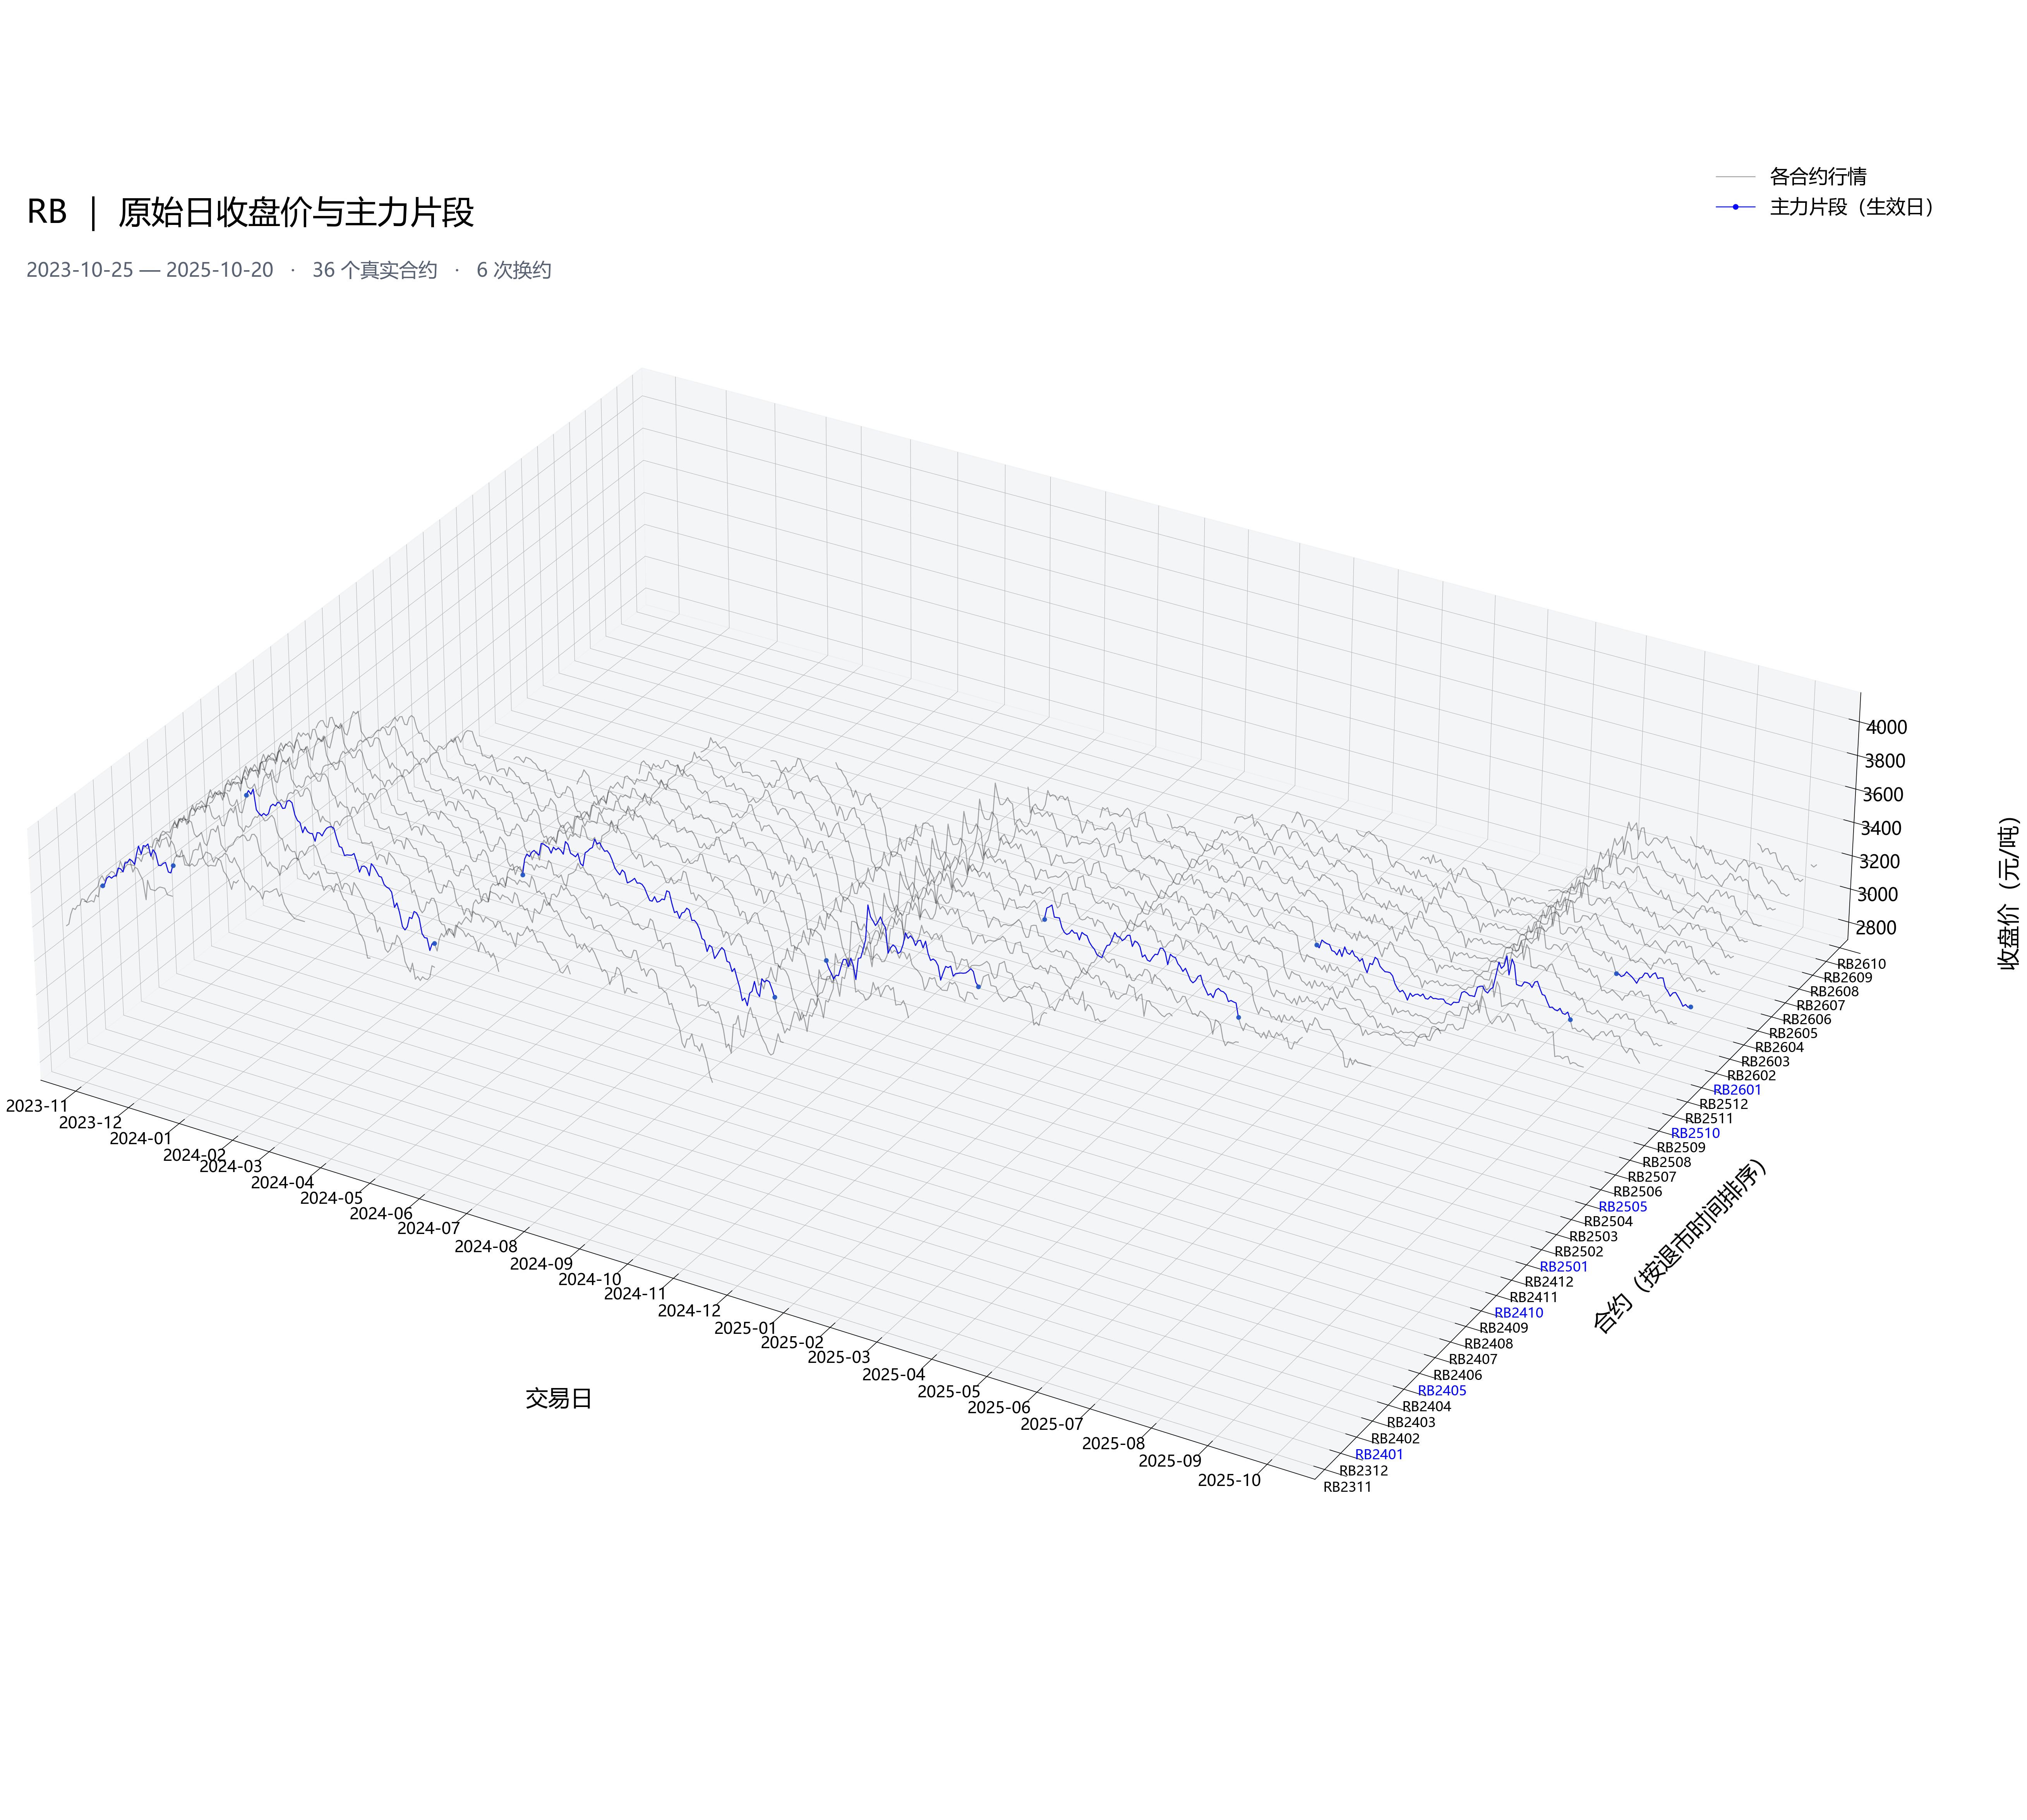

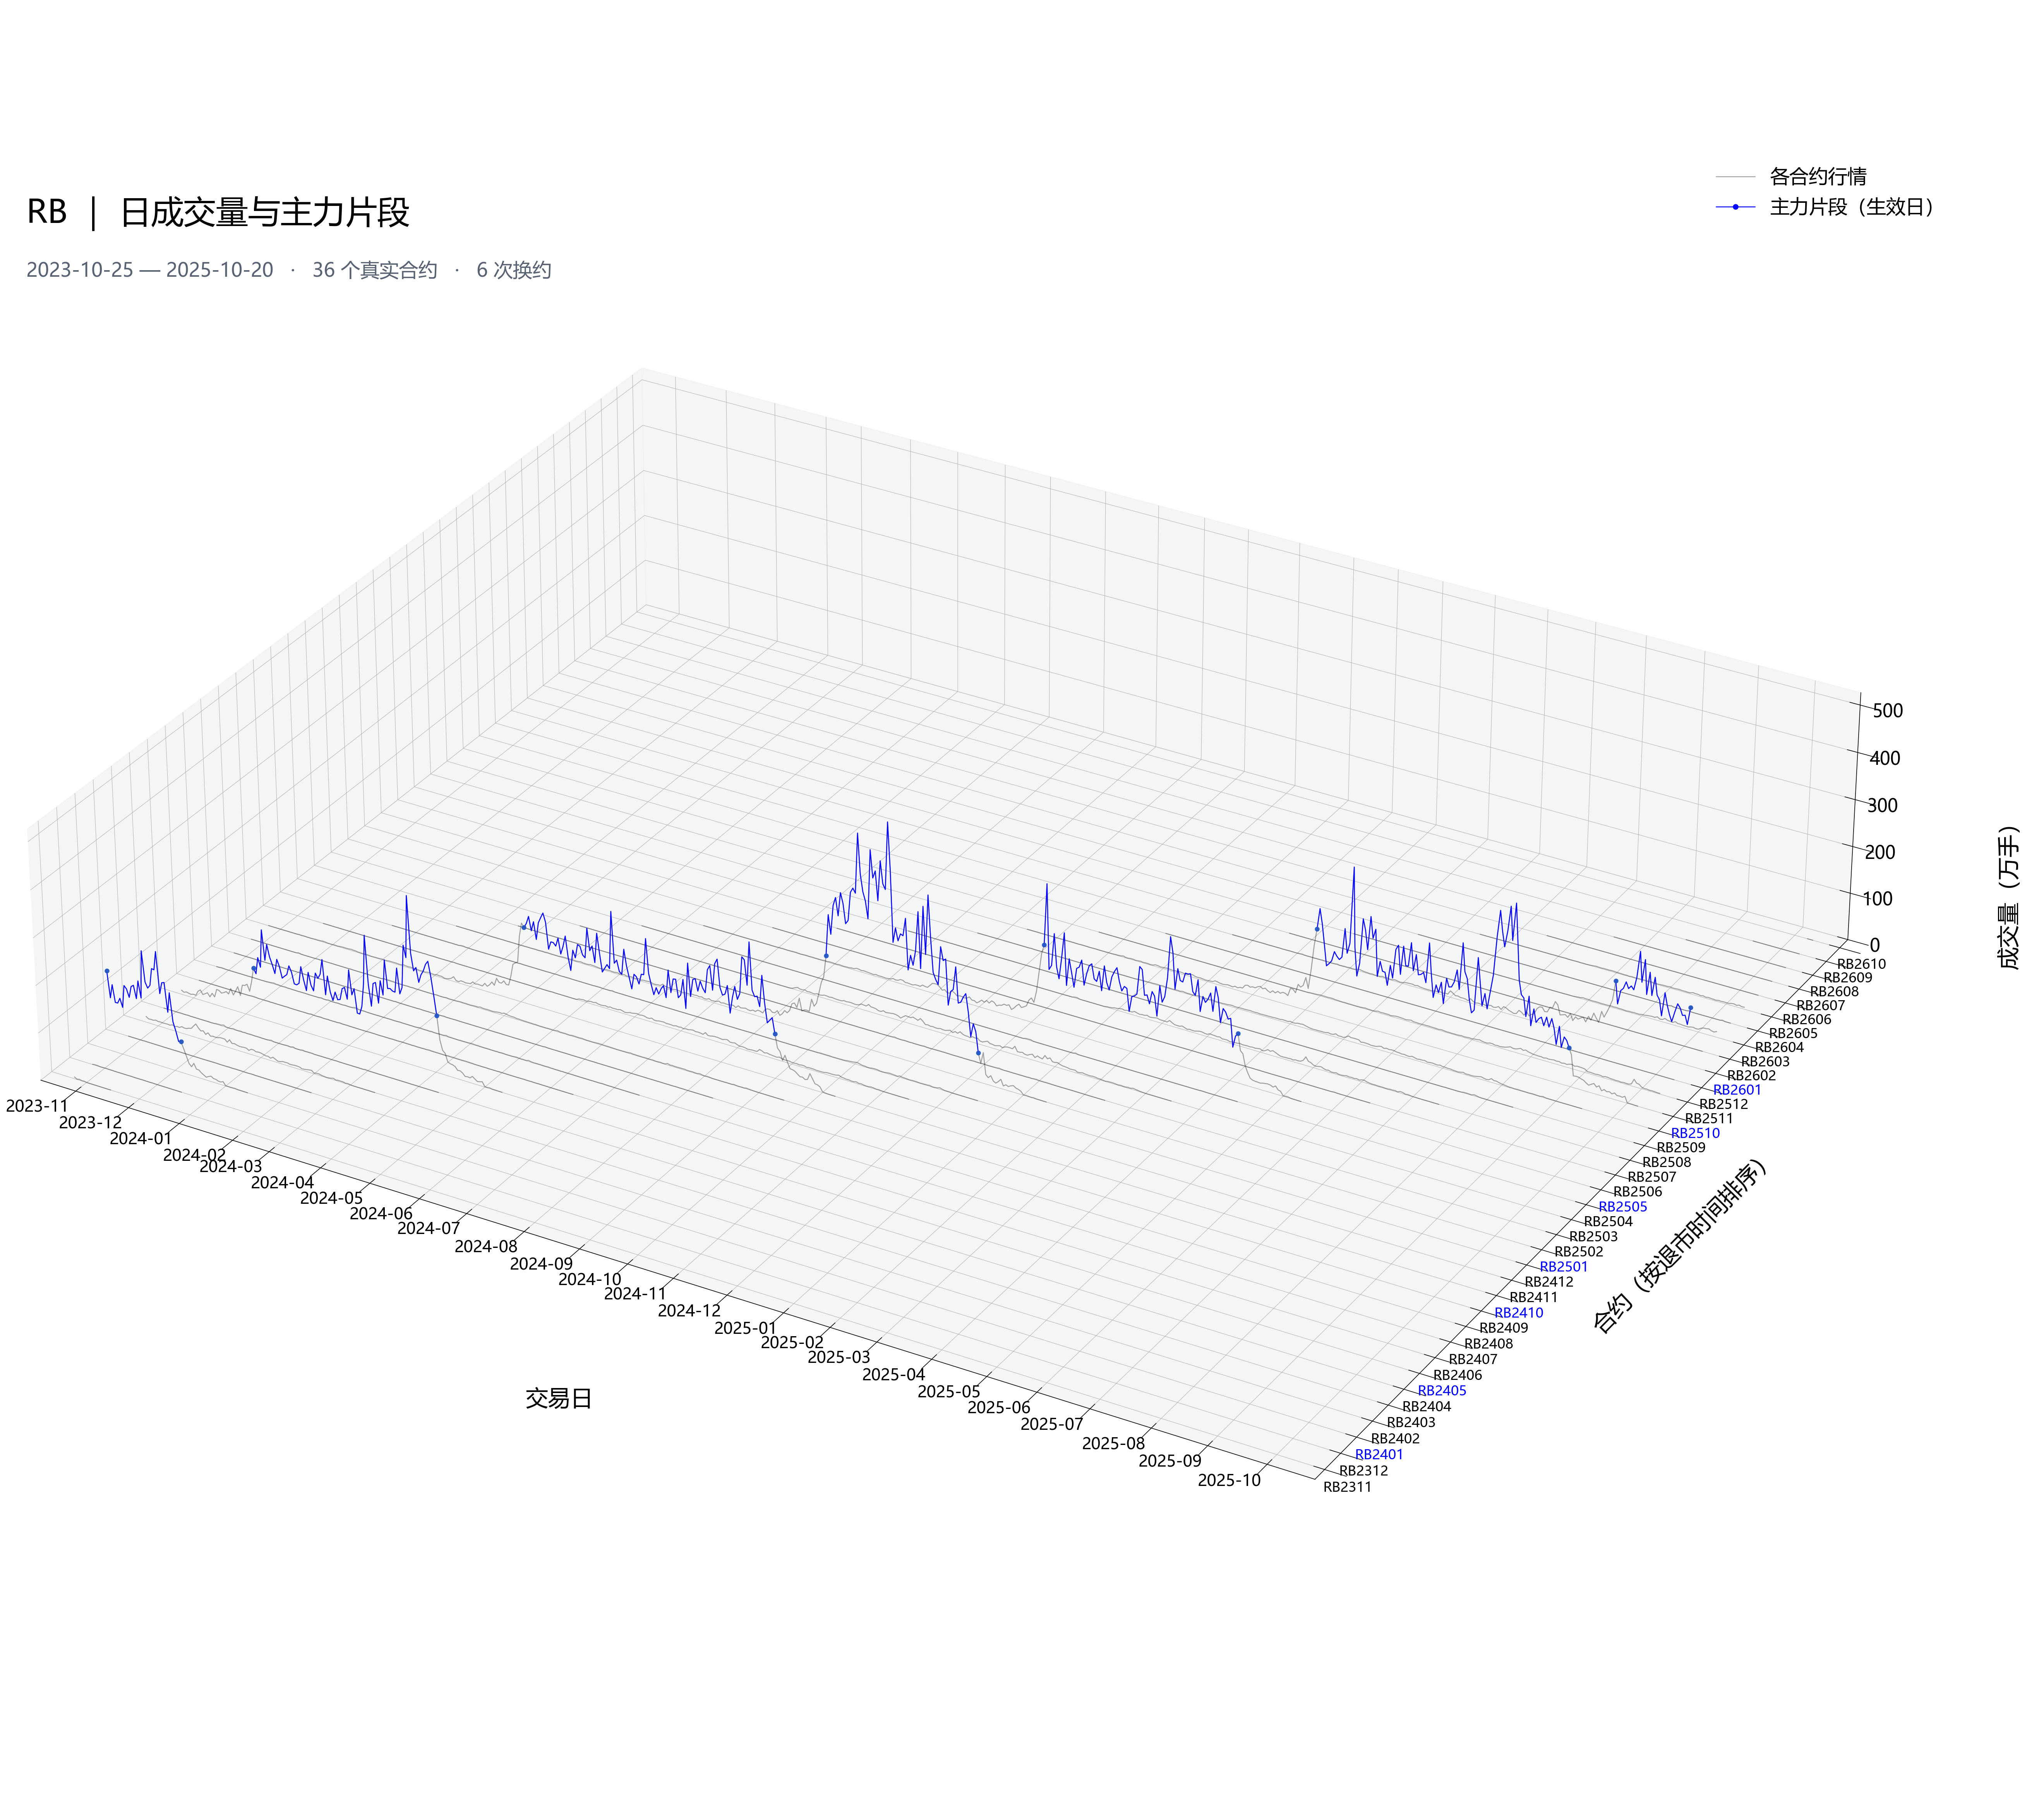

In [16]:
import matplotlib.pyplot as plt

# 展示范围只裁剪已有映射，不改变主力识别的历史范围。
plot_start_date = date(2023, 10, 25)
plot_end_date = date(2025, 10, 20)
price_figure, volume_figure = plot_main_contract_daily(
    daily_df, contract_calendar_df, main_contract_daily_df,
    exchange_code=demo_exchange_code,
    underlying_code=demo_underlying_code,
    plot_start_date=plot_start_date,
    plot_end_date=plot_end_date,
    price_unit="元/吨",
)
for plot_figure in (price_figure, volume_figure):
    display(plot_figure)
    plt.close(plot_figure)
